# Time Series Stockout Modeling - Objective and Plan

## Objective
Build an iterative station-level time series workflow that predicts when a BIXI station may run out of bikes using cumulative net flow versus capacity.

## Business Context
- Hourly estimation is required for operations.
- We start simple and increase complexity only when validated by results.

## Technical Target
1. Read rides from `data/silver/rides/` and inspect structure.
2. Use the first available `canonical_station_id` as the pilot station.
3. Build inflow, outflow, and net-flow time series (daily and hourly).
4. Estimate stockout risk over horizon `X` (start with 12 hours).
5. Support user-provided initial bikes and capacity; default initial bikes to 50% of capacity when unknown.

## Task-Gated Plan
- Task 1: Load silver rides and validate schema/time fields.
- Task 2: Retrieve station capacity by linking live station feed to canonical IDs via `CanonicalStationResolver` logic.
- Task 3: Build station-level inflow/outflow aggregates (daily first, then hourly).
- Task 4: Baseline forecasts and objective check.
- Task 5: Cumulative net-flow stockout simulation for horizon X.

## Decision Gate Rule
After each task execution, we explicitly check if results indicate a dead end and adjust objectives/approach before moving forward.

## Task 1 - Load and Inspect Silver Rides

### Objective
Confirm key columns needed for station-level time series modeling (canonical station id fields, timestamp fields, and ride-direction fields).

### Exit Criteria
- Identify at least one canonical station id field.
- Identify timestamp fields to build hourly and daily aggregates.
- Select the first pilot `canonical_station_id`.

In [12]:
from pathlib import Path
import pandas as pd
import numpy as np

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = (
    SparkSession.builder
    .appName("bixi-timeseries-eda")
    .master("local[*]")
    .getOrCreate()
    )

spark.conf.set("spark.sql.session.timeZone", "America/Toronto")
print("Spark version:", spark.version)

Spark version: 4.0.1


In [13]:
rides_path = Path("data/silver/rides")
if not rides_path.exists():
    raise FileNotFoundError(f"Missing rides path: {rides_path}")

rides_df = spark.read.parquet(str(rides_path))
print("Rides partitions loaded from:", rides_path)
print("Row count:", f"{rides_df.count():,}")
print("Column count:", len(rides_df.columns))

print("\nSchema:")
rides_df.printSchema()

candidate_station_cols = [c for c in rides_df.columns if "canonical_station_id" in c]
candidate_time_cols = [c for c in rides_df.columns if any(k in c.lower() for k in ["time", "date", "ts", "timestamp"])]

print("\nCandidate canonical station columns:", candidate_station_cols)
print("Candidate time/date columns:", candidate_time_cols)

display(rides_df.limit(10).toPandas())

Rides partitions loaded from: data/silver/rides
Row count: 27,588,048
Column count: 19

Schema:
root
 |-- end_station_key: string (nullable = true)
 |-- start_station_key: string (nullable = true)
 |-- start_station_name: string (nullable = true)
 |-- start_station_district: string (nullable = true)
 |-- start_station_latitude: double (nullable = true)
 |-- start_station_longitude: double (nullable = true)
 |-- end_station_name: string (nullable = true)
 |-- end_station_district: string (nullable = true)
 |-- end_station_latitude: double (nullable = true)
 |-- end_station_longitude: double (nullable = true)
 |-- start_time_ms: timestamp (nullable = true)
 |-- end_time_ms: timestamp (nullable = true)
 |-- start_station_name_norm: string (nullable = true)
 |-- end_station_name_norm: string (nullable = true)
 |-- start_coord_key: string (nullable = true)
 |-- end_coord_key: string (nullable = true)
 |-- start_canonical_station_id: string (nullable = true)
 |-- end_canonical_station_id: st

,end_station_key,start_station_key,start_station_name,start_station_district,start_station_latitude,start_station_longitude,end_station_name,end_station_district,end_station_latitude,end_station_longitude,start_time_ms,end_time_ms,start_station_name_norm,end_station_name_norm,start_coord_key,end_coord_key,start_canonical_station_id,end_canonical_station_id,ride_year
0,"45.531664,-73.565364|gauthier / de lorimier","45.513723,-73.560310|st-denis / ste-catherine",St-Denis / Ste-Catherine,Ville-Marie,45.513723,-73.560310,Gauthier / de Lorimier,Le Plateau-Mont-Royal,45.531664,-73.565364,2024-11-18 16:55:45,2024-11-18 17:09:03,st-denis / ste-catherine,gauthier / de lorimier,"45.513723,-73.560310","45.531664,-73.565364",STN_0066,STN_0140,2024
1,"45.512621,-73.573728|prince-arthur / st-urbain","45.516897,-73.589108|parc jeanne-mance (du mon...",Parc Jeanne-Mance (du Mont-Royal / du Parc),Le Plateau-Mont-Royal,45.516897,-73.589108,Prince-Arthur / St-Urbain,Le Plateau-Mont-Royal,45.512621,-73.573728,2024-05-11 15:02:24,2024-05-11 15:09:52,parc jeanne-mance (du mont-royal / du parc),prince-arthur / st-urbain,"45.516897,-73.589108","45.512621,-73.573728",STN_0169,STN_0294,2024
2,"45.531664,-73.565364|gauthier / de lorimier","45.526945,-73.580053|de mentana / du mont-royal",de Mentana / du Mont-Royal,Le Plateau-Mont-Royal,45.526945,-73.580053,Gauthier / de Lorimier,Le Plateau-Mont-Royal,45.531664,-73.565364,2024-11-18 20:31:43,2024-11-18 20:39:09,de mentana / du mont-royal,gauthier / de lorimier,"45.526945,-73.580053","45.531664,-73.565364",STN_0069,STN_0140,2024
3,"45.539385,-73.541000|ste-catherine / dézéry","45.548145,-73.547126|parc lalancette (de rouen...",Parc Lalancette (de Rouen / Valois),Mercier - Hochelaga-Maisonneuve,45.548145,-73.547126,Ste-Catherine / Dézéry,Mercier - Hochelaga-Maisonneuve,45.539385,-73.541000,2024-06-10 09:02:22,2024-06-10 09:08:16,parc lalancette (de rouen / valois),ste-catherine / dézéry,"45.548145,-73.547126","45.539385,-73.541000",STN_0275,STN_0222,2024
4,"45.520030,-73.554915|panet / ste-catherine","45.515228,-73.575096|des pins / st-laurent",des Pins / St-Laurent,Le Plateau-Mont-Royal,45.515228,-73.575096,Panet / Ste-Catherine,Ville-Marie,45.520030,-73.554915,2024-11-18 23:29:11,2024-11-18 23:39:27,des pins / st-laurent,panet / ste-catherine,"45.515228,-73.575096","45.520030,-73.554915",STN_0004,STN_0603,2024
5,"45.543102,-73.616075|boyer / everett","45.547582,-73.665229|clark / fleury",Clark / Fleury,Ahuntsic-Cartierville,45.547582,-73.665229,Boyer / Everett,Villeray—Saint-Michel—Parc-Extension,45.543102,-73.616075,2024-06-10 08:26:00,2024-06-10 08:45:48,clark / fleury,boyer / everett,"45.547582,-73.665229","45.543102,-73.616075",STN_0682,STN_0353,2024
6,"45.514482,-73.556873|st-hubert / rené-levesque","45.539385,-73.541000|ste-catherine / dézéry",Ste-Catherine / Dézéry,Mercier - Hochelaga-Maisonneuve,45.539385,-73.541000,St-Hubert / René-Levesque,Ville-Marie,45.514482,-73.556873,2024-11-18 15:37:40,2024-11-18 15:50:56,ste-catherine / dézéry,st-hubert / rené-levesque,"45.539385,-73.541000","45.514482,-73.556873",STN_0222,STN_0357,2024
7,"45.505274,-73.567479|st-alexandre / ste-catherine","45.522584,-73.593613|clark / laurier",Clark / Laurier,Le Plateau-Mont-Royal,45.522584,-73.593613,St-Alexandre / Ste-Catherine,Ville-Marie,45.505274,-73.567479,2024-06-10 09:08:37,2024-06-10 09:21:43,clark / laurier,st-alexandre / ste-catherine,"45.522584,-73.593613","45.505274,-73.567479",STN_0018,STN_0094,2024
8,"45.543560,-73.627772|métro jarry (lajeunesse /...","45.540780,-73.630401|de gaspé / jarry",de Gaspé / Jarry,Villeray—Saint-Michel—Parc-Extension,45.540780,-73.630401,Métro Jarry (Lajeunesse / Jarry),Villeray—Saint-Michel—Parc-Extension,45.543560,-73.627772,2024-11-18 14:01:03,2024-11-18 14:25:35,de gaspé / jarry,métro jarry (lajeunesse / jarry),"45.540780,-73.630401","45.543560,-73.627772",STN_0587,STN_0075,2024
9,"45.545230,-73.537250|valois / ste-catherine","45.538670,-73.569360|chapleau / du mont-royal",C

## Task 1 - Load and Inspect Silver Rides

### Objective
Confirm key columns needed for station-level time series modeling (canonical station id fields, timestamp fields, ride direction fields).

### Exit Criteria
- We can identify at least one canonical station id candidate field.
- We can identify timestamp fields to derive hourly and daily aggregates.
- We can pick the first station id for pilot modeling.

In [14]:
pilot_station_id = (
    rides_df
    .select(F.col("start_canonical_station_id").alias("canonical_station_id"))
    .where(F.col("canonical_station_id").isNotNull())
    .distinct()
    .orderBy("canonical_station_id")
    .limit(1)
    .collect()[0]["canonical_station_id"]
    )

print("Pilot canonical_station_id:", pilot_station_id)

coverage_counts = rides_df.select(
    F.count(F.when(F.col("start_canonical_station_id").isNotNull(), 1)).alias("start_id_non_null"),
    F.count(F.when(F.col("end_canonical_station_id").isNotNull(), 1)).alias("end_id_non_null"),
    F.count("*").alias("total_rows")
).toPandas()

display(coverage_counts)

Pilot canonical_station_id: STN_0001


,start_id_non_null,end_id_non_null,total_rows
0,27586805,27463463,27588048


In [38]:

p2_station_id = "STN_0833"

rides_df.select(
    F.col("start_canonical_station_id").alias("canonical_station_id")
).where(F.col("canonical_station_id") == p2_station_id).count()

6803

## Task 2 - Resolve Capacity for Pilot Canonical Station

### Objective
Use the `CanonicalStationResolver` logic and `live_stations_df` (with `capacity`) to estimate station capacity for the selected pilot `canonical_station_id`.

### Exit Criteria
- Select first pilot canonical station id from rides data.
- Build `live_stations_df` from live GBFS station feed.
- Map live stations to canonical IDs and compute capacity lookup by canonical station id.
- Retrieve capacity for pilot station id.

In [15]:
import re
import requests

# Load live station feed to get capacity at live-station granularity.
info_url = "https://gbfs.velobixi.com/gbfs/2-2/en/station_information.json"
info_data = requests.get(info_url, timeout=30).json()
live_stations_df = pd.DataFrame(info_data["data"]["stations"]).copy()

required_live_cols = ["station_id", "name", "capacity", "lat", "lon"]
missing_live_cols = [c for c in required_live_cols if c not in live_stations_df.columns]
if missing_live_cols:
    raise ValueError(f"Missing required live station columns: {missing_live_cols}")

print("Live stations:", len(live_stations_df))
display(live_stations_df[required_live_cols].head(10))

Live stations: 307


,station_id,name,capacity,lat,lon
0,3,Clark / Ontario,19,45.510494,-73.566921
1,15,Métro Berri-UQAM (St-Denis / de Maisonneuve),15,45.514252,-73.561502
2,17,Marché St-Jacques (Atateken),27,45.520666,-73.563915
3,19,Métro Sherbrooke (de Rigaud / Berri),27,45.518093,-73.568026
4,22,de la Commune / des Soeurs-Grises,67,45.497929,-73.552732
5,24,Notre-Dame / St-Gabriel,11,45.507173,-73.555087
6,25,de la Commune / Place Jacques-Cartier,81,45.507610,-73.551836
7,26,de Maisonneuve / Mansfield (sud),27,45.501827,-73.573642
8,31,Métro Place-d'Armes (St-Urbain / Viger),19,45.506323,-73.559699
9,34,Viger / Chenneville,37,45.505382,-73.560937


In [19]:
print(live_stations_df.sort_values("short_name").to_markdown())

|     |   station_id | external_id                          | name                                                               |   short_name |     lat |      lon | rental_methods        |   capacity | electric_bike_surcharge_waiver   | is_charging   | eightd_has_key_dispenser   | has_kiosk   |
|----:|-------------:|:-------------------------------------|:-------------------------------------------------------------------|-------------:|--------:|---------:|:----------------------|-----------:|:---------------------------------|:--------------|:---------------------------|:------------|
|   0 |            3 | 0b0fe114-08f3-11e7-a1cb-3863bb33a4e4 | Clark / Ontario                                                    |         6003 | 45.5105 | -73.5669 | ['KEY', 'CREDITCARD'] |         19 | False                            | False         | False                      | True        |
|   1 |           15 | 0b0ffa68-08f3-11e7-a1cb-3863bb33a4e4 | Métro Berri-UQAM (St-Denis / de Maisonneuve)

In [16]:
mapping_parquet_dir = Path("data/silver/station_cleaning/station_direct_match_mapping")
mapping_csv_dir = Path("data/silver/station_cleaning/station_direct_match_mapping_csv")

if mapping_parquet_dir.exists():
    canonical_mapping_df = pd.read_parquet(mapping_parquet_dir)
    mapping_source = str(mapping_parquet_dir)
elif mapping_csv_dir.exists():
    csv_parts = sorted(mapping_csv_dir.glob("part-*.csv"))
    if not csv_parts:
        raise FileNotFoundError(f"No mapping CSV parts found in {mapping_csv_dir}")
    canonical_mapping_df = pd.read_csv(csv_parts[0])
    mapping_source = str(csv_parts[0])
else:
    raise FileNotFoundError(
        f"Expected mapping in {mapping_parquet_dir} or {mapping_csv_dir}"
    )

required_map_cols = [
    "canonical_station_id",
    "canonical_lat",
    "canonical_lon",
    "normalized_name",
    "coord_key",
]
missing_map_cols = [c for c in required_map_cols if c not in canonical_mapping_df.columns]
if missing_map_cols:
    raise ValueError(f"Missing required mapping columns: {missing_map_cols}")

print("Mapping source:", mapping_source)
print("Mapping rows:", f"{len(canonical_mapping_df):,}")
print("Canonical stations:", canonical_mapping_df["canonical_station_id"].nunique())
display(canonical_mapping_df[required_map_cols].head(10))

Mapping source: data/silver/station_cleaning/station_direct_match_mapping
Mapping rows: 1,901
Canonical stations: 1423


,canonical_station_id,canonical_lat,canonical_lon,normalized_name,coord_key
0,STN_1371,0.000000,0.000000,9599 (test cyclochrome),"0.000000,0.000000"
1,STN_1371,0.000000,0.000000,cyclo pbsc,"0.000000,0.000000"
2,STN_1371,0.000000,0.000000,cyclo winter station,"0.000000,0.000000"
3,STN_1371,0.000000,0.000000,mtl-eco4-lab-03,"0.000000,0.000000"
4,STN_1371,0.000000,0.000000,mtl-lab-20-docks,"0.000000,0.000000"
5,STN_1371,0.000000,0.000000,test eco5.1.1,"0.000000,0.000000"
6,STN_1203,45.379756,-71.928778,u. de sherbrooke (pavillon de la vie étudiante...,"45.379756,-71.928778"
7,STN_1203,45.379756,-71.928778,u. de sherbrooke (registrariat-voie 3),"45.379756,-71.928778"
8,STN_1196,45.379850,-71.924395,u. de sherbrooke (pavillon marie-victorin-voie 1),"45.379850,-71.924395"
9,STN_1196,45.379850,-71.924395,u. de sherbrooke (école de musique-voie 1),"45.379850,-71.924395"


In [44]:
canonical_mapping_df[canonical_mapping_df["canonical_station_id"].isin([p2_station_id, pilot_station_id])]

,station_key,coord_key,normalized_name,canonical_station_id,canonical_coord_key,canonical_lat,canonical_lon,cluster_id,cluster_size,observed_trip_count,first_year_seen,last_year_seen
995,"45.524236,-73.581552|métro mont-royal (utilité...","45.524236,-73.581552",métro mont-royal (utilités publiques / rivard),STN_0001,"45.524353,-73.581432",45.524353,-73.581432,cluster_000727,3,215938,2024,2024
996,"45.524247,-73.581662|métro mont-royal (utilité...","45.524247,-73.581662",métro mont-royal (utilités publiques / rivard),STN_0001,"45.524353,-73.581432",45.524353,-73.581432,cluster_000727,3,27182,2024,2025
999,"45.524353,-73.581432|métro mont-royal (utilité...","45.524353,-73.581432",métro mont-royal (utilités publiques / rivard),STN_0001,"45.524353,-73.581432",45.524353,-73.581432,cluster_000727,3,230982,2025,2025
1003,"45.524420,-73.581663|métro mont-royal (place g...","45.524420,-73.581663",métro mont-royal (place gérald-godin),STN_0833,"45.524420,-73.581663",45.524420,-73.581663,cluster_000729,1,13507,2025,2026


In [45]:
print(canonical_mapping_df[canonical_mapping_df["canonical_station_id"].isin([p2_station_id, pilot_station_id])].station_key.to_markdown())

|      | station_key                                                         |
|-----:|:--------------------------------------------------------------------|
|  995 | 45.524236,-73.581552|métro mont-royal (utilités publiques / rivard) |
|  996 | 45.524247,-73.581662|métro mont-royal (utilités publiques / rivard) |
|  999 | 45.524353,-73.581432|métro mont-royal (utilités publiques / rivard) |
| 1003 | 45.524420,-73.581663|métro mont-royal (place gérald-godin)          |


In [46]:
resolver = CanonicalStationResolver(canonical_mapping_df)
resolver._haversine_km_vec(45.524353,-73.581432	,45.524420,-73.581663	)

np.float64(0.019476943769942152)

In [21]:
class CanonicalStationResolver:
    def __init__(self, canonical_mapping: pd.DataFrame, max_name_coord_km: float = 0.05, max_nearest_km: float = 0.05):
        required_cols = {
            "canonical_station_id", "canonical_lat", "canonical_lon", "normalized_name", "coord_key"
        }
        missing = required_cols - set(canonical_mapping.columns)
        if missing:
            raise ValueError(f"canonical_mapping is missing columns: {sorted(missing)}")

        self.max_name_coord_km = float(max_name_coord_km)
        self.max_nearest_km = float(max_nearest_km)

        self.canon_unique_df = (
            canonical_mapping[["canonical_station_id", "canonical_lat", "canonical_lon", "normalized_name", "coord_key"]]
            .dropna(subset=["canonical_station_id", "canonical_lat", "canonical_lon"])
            .drop_duplicates()
            .copy()
        )
        self.coord_to_station = dict(
            self.canon_unique_df[["coord_key", "canonical_station_id"]].drop_duplicates("coord_key").values
        )
        self.by_name = {k: v.reset_index(drop=True) for k, v in self.canon_unique_df.groupby("normalized_name")}
        self.canon_station_centers = (
            self.canon_unique_df[["canonical_station_id", "canonical_lat", "canonical_lon"]]
            .drop_duplicates("canonical_station_id")
            .reset_index(drop=True)
        )
        self.center_lats = self.canon_station_centers["canonical_lat"].to_numpy()
        self.center_lons = self.canon_station_centers["canonical_lon"].to_numpy()

    @staticmethod
    def _normalize_station_name(text: str) -> str:
        if text is None:
            return ""
        text = str(text).strip().lower()
        text = re.sub(r"\s+", " ", text)
        text = re.sub(r"\s*/\s*", " / ", text)
        text = re.sub(r"\s*-\s*", "-", text)
        return text.strip()

    @staticmethod
    def _haversine_km_vec(lat1, lon1, lat2, lon2):
        r = 6371.0
        lat1_rad = np.radians(lat1)
        lon1_rad = np.radians(lon1)
        lat2_rad = np.radians(lat2)
        lon2_rad = np.radians(lon2)
        dlat = lat2_rad - lat1_rad
        dlon = lon2_rad - lon1_rad
        a = np.sin(dlat / 2) ** 2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon / 2) ** 2
        return 2 * r * np.arcsin(np.sqrt(a))

    def resolve(self, raw_name: str, lat: float, lon: float) -> dict:
        normalized_name = self._normalize_station_name(raw_name)
        coord_key = f"{float(lat):.6f},{float(lon):.6f}"

        station_id = self.coord_to_station.get(coord_key)
        if station_id is not None:
            return {"canonical_station_id": station_id, "match_method": "exact_coord_key", "match_distance_km": 0.0}

        if normalized_name in self.by_name:
            cand = self.by_name[normalized_name]
            dists = self._haversine_km_vec(
                float(lat), float(lon), cand["canonical_lat"].to_numpy(), cand["canonical_lon"].to_numpy()
            )
            min_pos = int(np.argmin(dists))
            min_dist = float(dists[min_pos])
            if min_dist <= self.max_name_coord_km:
                return {
                    "canonical_station_id": cand.iloc[min_pos]["canonical_station_id"],
                    "match_method": "exact_normalized_name_nearest_coord",
                    "match_distance_km": min_dist,
                }

        dists = self._haversine_km_vec(float(lat), float(lon), self.center_lats, self.center_lons)
        min_pos = int(np.argmin(dists))
        min_dist = float(dists[min_pos])
        if min_dist <= self.max_nearest_km:
            return {
                "canonical_station_id": self.canon_station_centers.iloc[min_pos]["canonical_station_id"],
                "match_method": "nearest_canonical_within_0.05km",
                "match_distance_km": min_dist,
            }
        return {"canonical_station_id": None, "match_method": "unmatched", "match_distance_km": np.nan}

resolver = CanonicalStationResolver(canonical_mapping_df)

resolved_records = []
for _, row in live_stations_df.iterrows():
    r = resolver.resolve(row["name"], row["lat"], row["lon"])
    resolved_records.append({
        "station_id": row["station_id"],
        "name": row["name"],
        "capacity": row["capacity"],
        "lat": row["lat"],
        "lon": row["lon"],
        "canonical_station_id": r["canonical_station_id"],
        "match_method": r["match_method"],
        "match_distance_km": r["match_distance_km"],
    })

live_to_canonical_df = pd.DataFrame(resolved_records)
match_breakdown = live_to_canonical_df["match_method"].value_counts(dropna=False).rename_axis("match_method").reset_index(name="count")
print("Live-to-canonical match breakdown:")
display(match_breakdown)

canonical_capacity_df = (
    live_to_canonical_df.dropna(subset=["canonical_station_id", "capacity"])
    .groupby("canonical_station_id", as_index=False)
    .agg(capacity=("capacity", "max"), mapped_live_station_count=("station_id", "nunique"))
)

pilot_capacity_row = canonical_capacity_df[canonical_capacity_df["canonical_station_id"] == pilot_station_id]
if pilot_capacity_row.empty:
    pilot_capacity = np.nan
else:
    pilot_capacity = float(pilot_capacity_row.iloc[0]["capacity"] )

print(f"Pilot station {pilot_station_id} inferred capacity:", pilot_capacity)
display(pilot_capacity_row if not pilot_capacity_row.empty else canonical_capacity_df.head(10))

Live-to-canonical match breakdown:


,match_method,count
0,exact_coord_key,298
1,exact_normalized_name_nearest_coord,8
2,nearest_canonical_within_0.05km,1


Pilot station STN_0001 inferred capacity: nan


,canonical_station_id,capacity,mapped_live_station_count
0,STN_0002,39,1
1,STN_0003,37,1
2,STN_0004,23,1
3,STN_0005,31,1
4,STN_0006,81,1
5,STN_0007,49,1
6,STN_0009,19,1
7,STN_0010,32,1
8,STN_0011,24,1
9,STN_0012,54,1


In [29]:
live_stations_df[live_stations_df["short_name"] == "6345"]

,station_id,external_id,name,short_name,lat,lon,rental_methods,capacity,electric_bike_surcharge_waiver,is_charging,eightd_has_key_dispenser,has_kiosk
100,347,0b13e231-08f3-11e7-a1cb-3863bb33a4e4,Métro Mont-Royal (Place Gérald-Godin),6345,45.52442,-73.581663,"[KEY, CREDITCARD]",24,False,False,False,True


In [37]:
row = live_stations_df.loc[100]
r = resolver.resolve(row["name"], row["lat"], row["lon"])
{
        "station_id": row["station_id"],
        "name": row["name"],
        "capacity": row["capacity"],
        "lat": row["lat"],
        "lon": row["lon"],
        "canonical_station_id": r["canonical_station_id"],
        "match_method": r["match_method"],
        "match_distance_km": r["match_distance_km"],
    }

{'station_id': '347',
 'name': 'Métro Mont-Royal (Place Gérald-Godin)',
 'capacity': np.int64(24),
 'lat': np.float64(45.52442024398858),
 'lon': np.float64(-73.58166269028516),
 'canonical_station_id': 'STN_0833',
 'match_method': 'exact_coord_key',
 'match_distance_km': 0.0}

## Task 2 - Decision Gate

### Result Check
- Resolver-based mapping to canonical IDs worked for all live stations (307/307).
- Pilot station `STN_0001` has no live capacity mapping (likely inactive/legacy).

### Objective Shift
- Keep pilot station as requested (`first canonical id`).
- Add `capacity_override` input for stockout simulation.
- If override is not provided and live lookup is missing, use a documented fallback estimate for demonstration only.

## Task 3 - Build Daily and Hourly Time Series

### Objective
Construct station-level outflow, inflow, and net-flow time series for the pilot station, starting with daily summary and then hourly detail.

### Exit Criteria
- Daily and hourly tables created for `STN_0001`.
- Zero-filled regular hourly index prepared for forecasting.
- Basic diagnostics (coverage and seasonality hints) reviewed.

In [47]:
# User-configurable inputs (can be overridden).
horizon_hours = 12
capacity_override = 24  # e.g. set to 40 if known from operations.
initial_bikes_override = None  # e.g. set to 20 if known snapshot exists.

fallback_capacity_estimate = float(canonical_capacity_df["capacity"].median()) if len(canonical_capacity_df) else np.nan
station_capacity = float(capacity_override) if capacity_override is not None else (
    float(pilot_capacity) if pd.notna(pilot_capacity) else fallback_capacity_estimate
)
initial_bikes = (
    float(initial_bikes_override)
    if initial_bikes_override is not None
    else (0.5 * station_capacity if pd.notna(station_capacity) else np.nan)
)

print("horizon_hours:", horizon_hours)
print("station_capacity used:", station_capacity)
print("initial_bikes used:", initial_bikes)
print("capacity source:", "override" if capacity_override is not None else ("live-mapped" if pd.notna(pilot_capacity) else "fallback-median"))

horizon_hours: 12
station_capacity used: 24.0
initial_bikes used: 12.0
capacity source: override


In [48]:
outflow_hourly_sdf = (
    rides_df
    .where(F.col("start_canonical_station_id") == pilot_station_id)
    .where(F.col("start_time_ms").isNotNull())
    .groupBy(F.date_trunc("hour", F.col("start_time_ms")).alias("ts_hour"))
    .agg(F.count("*").alias("outflow"))
)

inflow_hourly_sdf = (
    rides_df
    .where(F.col("end_canonical_station_id") == pilot_station_id)
    .where(F.col("end_time_ms").isNotNull())
    .groupBy(F.date_trunc("hour", F.col("end_time_ms")).alias("ts_hour"))
    .agg(F.count("*").alias("inflow"))
)

hourly_sdf = (
    outflow_hourly_sdf.join(inflow_hourly_sdf, on="ts_hour", how="full")
    .fillna(0, subset=["outflow", "inflow"])
)

hourly_pd = hourly_sdf.orderBy("ts_hour").toPandas()
hourly_pd["ts_hour"] = pd.to_datetime(hourly_pd["ts_hour"])

hourly_pd = (
    hourly_pd.groupby("ts_hour", as_index=False)[["inflow", "outflow"]]
    .sum()
    .sort_values("ts_hour")
    .reset_index(drop=True)
)

if len(hourly_pd) == 0:
    raise ValueError(f"No hourly records found for pilot station {pilot_station_id}")

full_hour_index = pd.date_range(hourly_pd["ts_hour"].min(), hourly_pd["ts_hour"].max(), freq="h")
hourly_pd = (
    hourly_pd.set_index("ts_hour")
    .reindex(full_hour_index, fill_value=0)
    .rename_axis("ts_hour")
    .reset_index()
)
hourly_pd["net_flow"] = hourly_pd["inflow"] - hourly_pd["outflow"]

daily_pd = (
    hourly_pd.set_index("ts_hour")[["inflow", "outflow", "net_flow"]]
    .resample("D")
    .sum()
    .reset_index()
)

print("Hourly rows:", len(hourly_pd))
print("Date range:", hourly_pd["ts_hour"].min(), "to", hourly_pd["ts_hour"].max())
print("Daily rows:", len(daily_pd))

display(hourly_pd.head(24))
display(daily_pd.head(10))

Hourly rows: 16334
Date range: 2024-01-01 00:00:00 to 2025-11-11 13:00:00
Daily rows: 681


,ts_hour,inflow,outflow,net_flow
0,2024-01-01 00:00:00,1,0,1
1,2024-01-01 01:00:00,3,2,1
2,2024-01-01 02:00:00,3,11,-8
3,2024-01-01 03:00:00,1,7,-6
4,2024-01-01 04:00:00,0,3,-3
5,2024-01-01 05:00:00,1,1,0
6,2024-01-01 06:00:00,1,0,1
7,2024-01-01 07:00:00,0,0,0
8,2024-01-01 08:00:00,0,0,0
9,2024-01-01 09:00:00,0,0,0


,ts_hour,inflow,outflow,net_flow
0,2024-01-01,23,43,-20
1,2024-01-02,50,52,-2
2,2024-01-03,61,53,8
3,2024-01-04,54,62,-8
4,2024-01-05,46,35,11
5,2024-01-06,33,30,3
6,2024-01-07,14,11,3
7,2024-01-08,34,38,-4
8,2024-01-09,27,22,5
9,2024-01-10,37,36,1


## Task 4 - Baseline Forecasting (Simple to More Detailed)

### Objective
Start with interpretable baselines and evaluate whether hourly forecasting is informative enough for stockout risk simulation.

### Baselines
1. Daily baseline: day-of-week average for inflow and outflow.
2. Hourly baseline: hour-of-week average for inflow and outflow.

### Exit Criteria
- Report holdout errors for daily and hourly baselines.
- Produce next `horizon_hours` forecast for inflow, outflow, and net flow.

Holdout hours: 336
Hourly baseline MAE - inflow: 5.473
Hourly baseline MAE - outflow: 6.654
Hourly baseline MAE - net_flow: 4.331
Daily baseline MAE - inflow: 180.900
Daily baseline MAE - outflow: 226.963
Daily baseline MAE - net_flow: 48.841


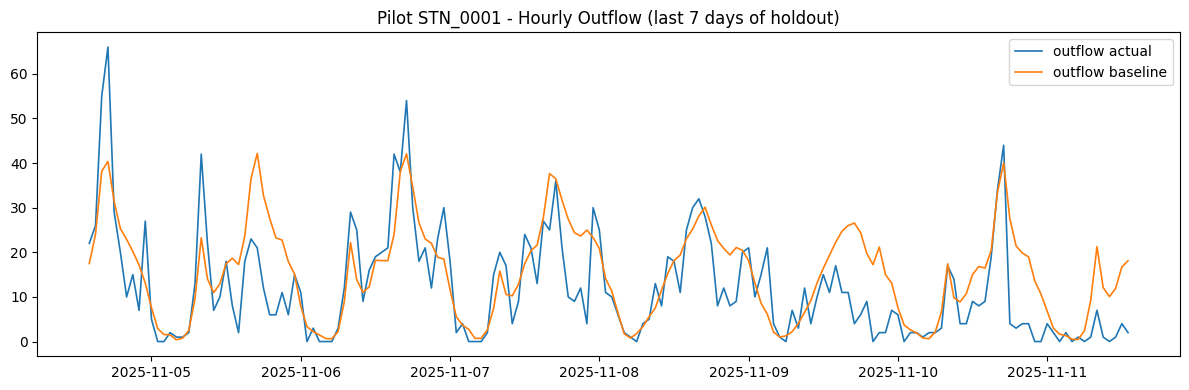

In [49]:
import matplotlib.pyplot as plt

hourly_model_pd = hourly_pd.copy()
hourly_model_pd["dow"] = hourly_model_pd["ts_hour"].dt.dayofweek
hourly_model_pd["hour"] = hourly_model_pd["ts_hour"].dt.hour
hourly_model_pd["hour_of_week"] = hourly_model_pd["dow"] * 24 + hourly_model_pd["hour"]

holdout_hours = min(14 * 24, max(24, len(hourly_model_pd) // 5))
train_pd = hourly_model_pd.iloc[:-holdout_hours].copy()
test_pd = hourly_model_pd.iloc[-holdout_hours:].copy()

if len(train_pd) < 24 * 14:
    raise ValueError("Not enough training history for stable baseline evaluation")

# Hourly seasonal baseline (hour-of-week means).
how_means = train_pd.groupby("hour_of_week")[["inflow", "outflow"]].mean()
global_means = train_pd[["inflow", "outflow"]].mean()

test_pred_hourly = test_pd[["ts_hour", "hour_of_week", "inflow", "outflow"]].copy()
test_pred_hourly = test_pred_hourly.join(how_means, on="hour_of_week", rsuffix="_pred")
test_pred_hourly["inflow_pred"] = test_pred_hourly["inflow_pred"].fillna(global_means["inflow"] )
test_pred_hourly["outflow_pred"] = test_pred_hourly["outflow_pred"].fillna(global_means["outflow"] )
test_pred_hourly["net_flow"] = test_pred_hourly["inflow"] - test_pred_hourly["outflow"]
test_pred_hourly["net_flow_pred"] = test_pred_hourly["inflow_pred"] - test_pred_hourly["outflow_pred"]

hourly_mae_in = (test_pred_hourly["inflow"] - test_pred_hourly["inflow_pred"]).abs().mean()
hourly_mae_out = (test_pred_hourly["outflow"] - test_pred_hourly["outflow_pred"]).abs().mean()
hourly_mae_net = (test_pred_hourly["net_flow"] - test_pred_hourly["net_flow_pred"]).abs().mean()

print("Holdout hours:", holdout_hours)
print(f"Hourly baseline MAE - inflow: {hourly_mae_in:.3f}")
print(f"Hourly baseline MAE - outflow: {hourly_mae_out:.3f}")
print(f"Hourly baseline MAE - net_flow: {hourly_mae_net:.3f}")

# Daily baseline (day-of-week).
daily_model_pd = daily_pd.copy()
daily_model_pd["dow"] = daily_model_pd["ts_hour"].dt.dayofweek
holdout_days = min(60, max(14, len(daily_model_pd) // 5))
train_daily = daily_model_pd.iloc[:-holdout_days].copy()
test_daily = daily_model_pd.iloc[-holdout_days:].copy()

daily_means = train_daily.groupby("dow")[["inflow", "outflow"]].mean()
daily_globals = train_daily[["inflow", "outflow"]].mean()

test_pred_daily = test_daily[["ts_hour", "dow", "inflow", "outflow"]].copy()
test_pred_daily = test_pred_daily.join(daily_means, on="dow", rsuffix="_pred")
test_pred_daily["inflow_pred"] = test_pred_daily["inflow_pred"].fillna(daily_globals["inflow"] )
test_pred_daily["outflow_pred"] = test_pred_daily["outflow_pred"].fillna(daily_globals["outflow"] )
test_pred_daily["net_flow"] = test_pred_daily["inflow"] - test_pred_daily["outflow"]
test_pred_daily["net_flow_pred"] = test_pred_daily["inflow_pred"] - test_pred_daily["outflow_pred"]

daily_mae_in = (test_pred_daily["inflow"] - test_pred_daily["inflow_pred"]).abs().mean()
daily_mae_out = (test_pred_daily["outflow"] - test_pred_daily["outflow_pred"]).abs().mean()
daily_mae_net = (test_pred_daily["net_flow"] - test_pred_daily["net_flow_pred"]).abs().mean()

print(f"Daily baseline MAE - inflow: {daily_mae_in:.3f}")
print(f"Daily baseline MAE - outflow: {daily_mae_out:.3f}")
print(f"Daily baseline MAE - net_flow: {daily_mae_net:.3f}")

# Quick visual on recent segment.
recent = test_pred_hourly.tail(24 * 7)
plt.figure(figsize=(12, 4))
plt.plot(recent["ts_hour"], recent["outflow"], label="outflow actual", linewidth=1.2)
plt.plot(recent["ts_hour"], recent["outflow_pred"], label="outflow baseline", linewidth=1.2)
plt.title(f"Pilot {pilot_station_id} - Hourly Outflow (last 7 days of holdout)")
plt.legend()
plt.tight_layout()
plt.show()

## Task 4.1 - Error Diagnostics (Why Baseline Error Is High)

### Objective
Visualize where the hourly baseline fails and quantify the main drivers of error.

### Questions
1. Are errors concentrated at certain hours/days?
2. Are spikes causing most of the miss?
3. Is there distribution shift between train and holdout windows?

### Exit Criteria
- Error decomposition tables generated.
- Diagnostic plots generated.
- Clear explanation of high-error mechanisms documented.

Spike threshold (95th percentile train outflow): 54.00
Outflow MAE (holdout): 6.654
Inflow MAE (holdout): 5.473
Net-flow MAE (holdout): 4.331
Outflow MAPE (non-zero actuals): 85.44%


,hour,mae_outflow,mae_inflow,mae_net,obs
0,0,4.061717,3.341667,3.929323,14
1,1,3.174906,2.599232,3.098951,14
2,2,2.488518,1.625501,2.290805,14
3,3,2.102256,1.192152,2.094204,14
4,4,0.812453,0.509273,0.729057,14
5,5,0.706234,2.171538,2.289019,14
6,6,1.386466,3.750376,2.491729,14
7,7,4.375188,6.008365,5.098794,14
8,8,7.157895,7.544236,3.490742,14
9,9,6.598230,3.628430,3.781830,14


,dow,mae_outflow,mae_inflow,mae_net,mean_outflow
0,0,6.193576,5.353733,3.662326,9.812500
1,1,7.923113,6.101809,5.164638,17.416667
2,2,9.033553,6.977632,4.571711,17.687500
3,3,4.521491,4.620614,4.219737,15.875000
4,4,7.386842,6.322149,4.007675,11.541667
5,5,5.241228,4.331798,4.376535,13.833333
6,6,6.274781,4.604825,4.312061,11.145833


,is_spike_hour,n_hours,mae_outflow,mean_actual_outflow,mean_pred_outflow
0,False,329,6.216897,12.775076,14.797414
1,True,7,27.174436,66.857143,39.682707


,metric,value
0,train_outflow_mean,15.307163
1,test_outflow_mean,13.901786
2,train_inflow_mean,13.779097
3,test_inflow_mean,12.229167


,ts_hour,outflow,outflow_pred,abs_error_outflow,inflow,inflow_pred,abs_error_inflow
0,2025-10-29 16:00:00,75,36.463158,38.536842,60,25.715789,34.284211
1,2025-10-28 17:00:00,77,40.368421,36.631579,53,34.473684,18.526316
2,2025-10-29 17:00:00,73,42.168421,30.831579,45,35.663158,9.336842
3,2025-10-28 16:00:00,68,38.168421,29.831579,36,25.147368,10.852632
4,2025-11-04 17:00:00,66,40.368421,25.631579,48,34.473684,13.526316
5,2025-10-31 17:00:00,11,36.463158,25.463158,10,32.842105,22.842105
6,2025-11-10 18:00:00,4,27.500000,23.500000,5,25.677083,20.677083
7,2025-11-09 17:00:00,4,26.557895,22.557895,9,21.715789,12.715789
8,2025-11-05 19:00:00,6,27.642105,21.642105,11,25.315789,14.315789
9,2025-11-05 17:00:00,21,42.168421,21.168421,21,35.663158,14.663158


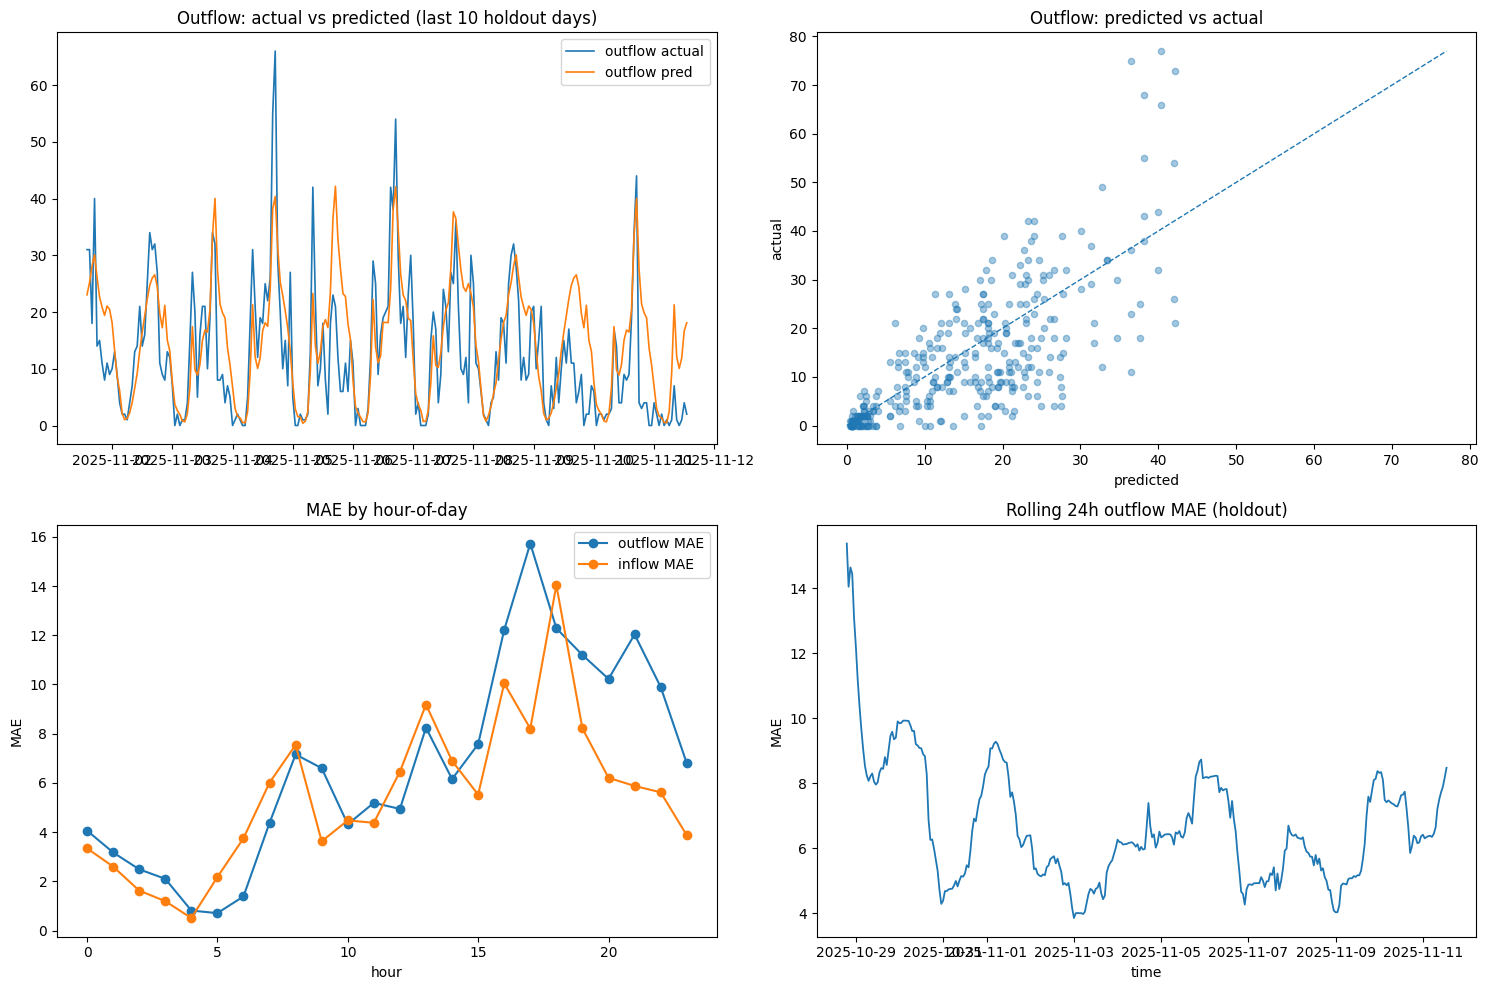

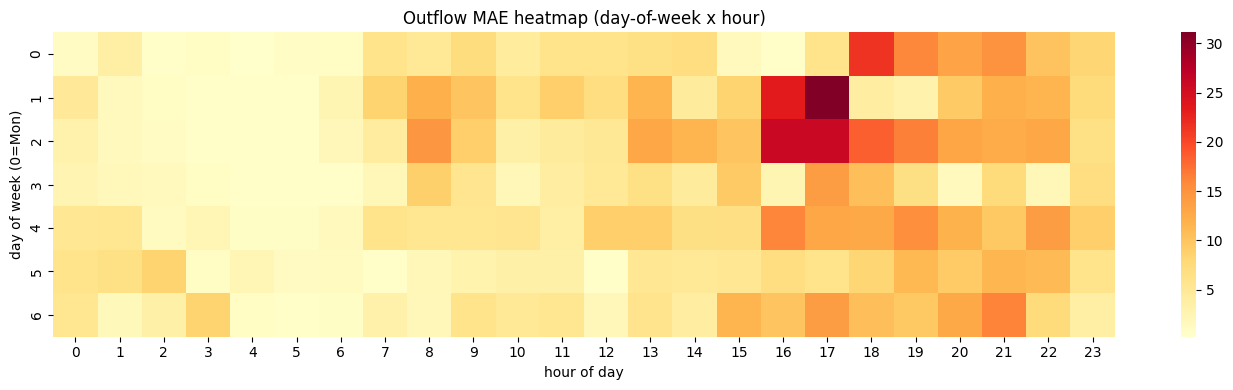

In [51]:
import seaborn as sns

diag = test_pred_hourly.copy()
diag["error_outflow"] = diag["outflow"] - diag["outflow_pred"]
diag["abs_error_outflow"] = diag["error_outflow"].abs()
diag["error_inflow"] = diag["inflow"] - diag["inflow_pred"]
diag["abs_error_inflow"] = diag["error_inflow"].abs()
diag["error_net"] = diag["net_flow"] - diag["net_flow_pred"]
diag["abs_error_net"] = diag["error_net"].abs()
diag["hour"] = diag["ts_hour"].dt.hour
diag["dow"] = diag["ts_hour"].dt.dayofweek

# Relative error can explode when actual is near zero; keep NaN for zero actuals.
diag["ape_outflow"] = np.where(diag["outflow"] > 0, diag["abs_error_outflow"] / diag["outflow"], np.nan)

error_by_hour = diag.groupby("hour", as_index=False).agg(
    mae_outflow=("abs_error_outflow", "mean"),
    mae_inflow=("abs_error_inflow", "mean"),
    mae_net=("abs_error_net", "mean"),
    obs=("hour", "count"),
)

error_by_dow = diag.groupby("dow", as_index=False).agg(
    mae_outflow=("abs_error_outflow", "mean"),
    mae_inflow=("abs_error_inflow", "mean"),
    mae_net=("abs_error_net", "mean"),
    mean_outflow=("outflow", "mean"),
)

# Spike sensitivity: compare high-demand hours vs normal hours using train quantile threshold.
spike_threshold = train_pd["outflow"].quantile(0.95)
diag["is_spike_hour"] = diag["outflow"] >= spike_threshold
spike_summary = diag.groupby("is_spike_hour", as_index=False).agg(
    n_hours=("is_spike_hour", "count"),
    mae_outflow=("abs_error_outflow", "mean"),
    mean_actual_outflow=("outflow", "mean"),
    mean_pred_outflow=("outflow_pred", "mean"),
)

# Drift check: does holdout mean level differ from training level?
drift_summary = pd.DataFrame({
    "metric": ["train_outflow_mean", "test_outflow_mean", "train_inflow_mean", "test_inflow_mean"],
    "value": [train_pd["outflow"].mean(), diag["outflow"].mean(), train_pd["inflow"].mean(), diag["inflow"].mean()],
})

top_misses = (
    diag[["ts_hour", "outflow", "outflow_pred", "abs_error_outflow", "inflow", "inflow_pred", "abs_error_inflow"]]
    .sort_values("abs_error_outflow", ascending=False)
    .head(20)
    .reset_index(drop=True)
)

print(f"Spike threshold (95th percentile train outflow): {spike_threshold:.2f}")
print(f"Outflow MAE (holdout): {diag['abs_error_outflow'].mean():.3f}")
print(f"Inflow MAE (holdout): {diag['abs_error_inflow'].mean():.3f}")
print(f"Net-flow MAE (holdout): {diag['abs_error_net'].mean():.3f}")
print(f"Outflow MAPE (non-zero actuals): {diag['ape_outflow'].mean() * 100:.2f}%")

display(error_by_hour)
display(error_by_dow)
display(spike_summary)
display(drift_summary)
display(top_misses)

# Visual diagnostics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

recent_diag = diag.tail(24 * 10)
axes[0, 0].plot(recent_diag["ts_hour"], recent_diag["outflow"], label="outflow actual", linewidth=1.2)
axes[0, 0].plot(recent_diag["ts_hour"], recent_diag["outflow_pred"], label="outflow pred", linewidth=1.2)
axes[0, 0].set_title("Outflow: actual vs predicted (last 10 holdout days)")
axes[0, 0].legend()

axes[0, 1].scatter(diag["outflow_pred"], diag["outflow"], alpha=0.4, s=20)
mx = max(diag["outflow"].max(), diag["outflow_pred"].max())
axes[0, 1].plot([0, mx], [0, mx], linestyle="--", linewidth=1)
axes[0, 1].set_title("Outflow: predicted vs actual")
axes[0, 1].set_xlabel("predicted")
axes[0, 1].set_ylabel("actual")

axes[1, 0].plot(error_by_hour["hour"], error_by_hour["mae_outflow"], marker="o", label="outflow MAE")
axes[1, 0].plot(error_by_hour["hour"], error_by_hour["mae_inflow"], marker="o", label="inflow MAE")
axes[1, 0].set_title("MAE by hour-of-day")
axes[1, 0].set_xlabel("hour")
axes[1, 0].set_ylabel("MAE")
axes[1, 0].legend()

rolling_mae = diag[["ts_hour", "abs_error_outflow"]].copy()
rolling_mae["rolling_24h_mae"] = rolling_mae["abs_error_outflow"].rolling(24, min_periods=6).mean()
axes[1, 1].plot(rolling_mae["ts_hour"], rolling_mae["rolling_24h_mae"], linewidth=1.3)
axes[1, 1].set_title("Rolling 24h outflow MAE (holdout)")
axes[1, 1].set_xlabel("time")
axes[1, 1].set_ylabel("MAE")

plt.tight_layout()
plt.show()

heat = diag.pivot_table(index="dow", columns="hour", values="abs_error_outflow", aggfunc="mean")
plt.figure(figsize=(14, 4))
sns.heatmap(heat, cmap="YlOrRd")
plt.title("Outflow MAE heatmap (day-of-week x hour)")
plt.ylabel("day of week (0=Mon)")
plt.xlabel("hour of day")
plt.tight_layout()
plt.show()

## Task 4.2 - Separate Lag-Feature Models (Inflow and Outflow)

### Objective
Train separate supervised models for inflow and outflow using lag and calendar features, then compare against the baseline hour-of-week method.

### Feature Set
- Lags: 1h, 2h, 24h, 48h, 168h
- Rolling means (shifted): 6h and 24h
- Calendar: hour-of-day and day-of-week cyclic terms + weekend flag

### Exit Criteria
- Separate model metrics for inflow and outflow.
- Baseline vs lag-model comparison table.
- Visual comparison over the recent holdout segment.

Lag-feature model metrics:


,series,baseline_mae,lag_model_mae,mae_delta
0,outflow,6.653512,5.779918,-0.873594
1,inflow,5.473223,5.101151,-0.372072


Top outflow coefficients (magnitude):


,feature,coef,abs_coef
0,lag_1,6.270858,6.270858
1,lag_168,5.496520,5.496520
2,lag_24,3.512659,3.512659
3,lag_48,1.829573,1.829573
4,hour_cos,-1.053981,1.053981
5,lag_2,0.729659,0.729659
6,roll_24_mean,0.709273,0.709273
7,hour_sin,-0.406088,0.406088


Top inflow coefficients (magnitude):


,feature,coef,abs_coef
0,lag_1,6.376806,6.376806
1,lag_168,4.456679,4.456679
2,lag_24,2.689339,2.689339
3,lag_48,1.088053,1.088053
4,roll_24_mean,1.039141,1.039141
5,roll_6_mean,-0.927408,0.927408
6,hour_cos,-0.807541,0.807541
7,lag_2,0.526573,0.526573


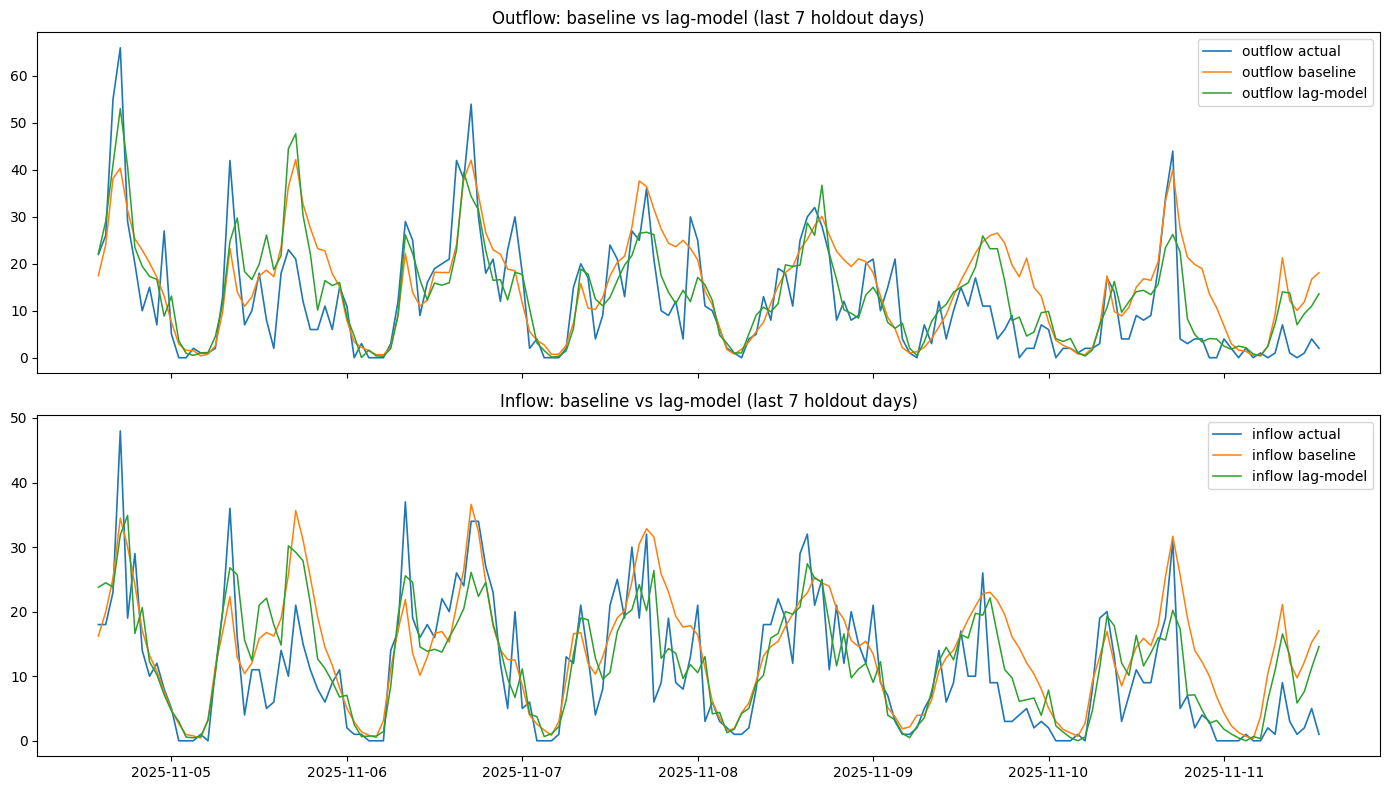

In [52]:
# Task 4.2: separate lag-feature models for outflow and inflow (no extra dependencies).
from typing import List, Tuple

def build_features(base_df: pd.DataFrame, target_col: str) -> pd.DataFrame:
    df = base_df[["ts_hour", target_col]].copy()
    df["hour"] = df["ts_hour"].dt.hour
    df["dow"] = df["ts_hour"].dt.dayofweek
    df["is_weekend"] = (df["dow"] >= 5).astype(int)

    # Cyclical calendar terms.
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24.0)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24.0)
    df["dow_sin"] = np.sin(2 * np.pi * df["dow"] / 7.0)
    df["dow_cos"] = np.cos(2 * np.pi * df["dow"] / 7.0)

    # Lag features from the target series.
    lag_cols = [1, 2, 24, 48, 168]
    for l in lag_cols:
        df[f"lag_{l}"] = df[target_col].shift(l)

    # Shift rolling windows by 1h to avoid leakage.
    df["roll_6_mean"] = df[target_col].shift(1).rolling(6).mean()
    df["roll_24_mean"] = df[target_col].shift(1).rolling(24).mean()

    return df

def fit_ridge_closed_form(
    X_train: np.ndarray,
    y_train: np.ndarray,
    alpha: float = 5.0,
    ) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    # Standardize columns for stable ridge estimation.
    x_mean = X_train.mean(axis=0)
    x_std = X_train.std(axis=0)
    x_std = np.where(x_std == 0, 1.0, x_std)

    Xs = (X_train - x_mean) / x_std
    y_mean = y_train.mean()
    y_centered = y_train - y_mean

    n_features = Xs.shape[1]
    reg = alpha * np.eye(n_features)
    beta = np.linalg.solve(Xs.T @ Xs + reg, Xs.T @ y_centered)

    return beta, x_mean, x_std

def predict_ridge(
    X: np.ndarray,
    beta: np.ndarray,
    x_mean: np.ndarray,
    x_std: np.ndarray,
    y_mean: float,
    ) -> np.ndarray:
    Xs = (X - x_mean) / x_std
    return y_mean + (Xs @ beta)

def train_eval_target(
    base_df: pd.DataFrame,
    target_col: str,
    holdout_n: int,
    alpha: float = 5.0,
    ) -> Tuple[pd.DataFrame, dict, pd.DataFrame]:
    feat_df = build_features(base_df, target_col)
    feat_df = feat_df.dropna().reset_index(drop=True)

    # Preserve chronological split.
    split_idx = len(feat_df) - holdout_n
    train = feat_df.iloc[:split_idx].copy()
    test = feat_df.iloc[split_idx:].copy()

    feature_cols = [
        "hour_sin", "hour_cos", "dow_sin", "dow_cos", "is_weekend",
        "lag_1", "lag_2", "lag_24", "lag_48", "lag_168",
        "roll_6_mean", "roll_24_mean",
    ]

    X_train = train[feature_cols].to_numpy(dtype=float)
    y_train = train[target_col].to_numpy(dtype=float)
    X_test = test[feature_cols].to_numpy(dtype=float)
    y_test = test[target_col].to_numpy(dtype=float)

    beta, x_mean, x_std = fit_ridge_closed_form(X_train, y_train, alpha=alpha)
    y_hat = predict_ridge(X_test, beta, x_mean, x_std, y_train.mean())
    y_hat = np.clip(y_hat, 0, None)

    pred_df = test[["ts_hour"]].copy()
    pred_df["actual"] = y_test
    pred_df["pred"] = y_hat
    pred_df["abs_err"] = (pred_df["actual"] - pred_df["pred"]).abs()
    pred_df["sq_err"] = (pred_df["actual"] - pred_df["pred"]) ** 2

    metrics = {
        "target": target_col,
        "mae": float(pred_df["abs_err"].mean()),
        "rmse": float(np.sqrt(pred_df["sq_err"].mean())),
        "mean_actual": float(pred_df["actual"].mean()),
    }

    coef_df = pd.DataFrame({
        "feature": feature_cols,
        "coef": beta,
        "abs_coef": np.abs(beta),
    }).sort_values("abs_coef", ascending=False).reset_index(drop=True)

    return pred_df, metrics, coef_df

# Use same holdout size as baseline section for fair comparison.
model_holdout = holdout_hours if "holdout_hours" in globals() else min(14 * 24, max(24, len(hourly_pd) // 5))

model_base_df = hourly_pd[["ts_hour", "inflow", "outflow"]].copy()

out_pred_df, out_metrics, out_coef = train_eval_target(
    model_base_df.rename(columns={"outflow": "target"})[["ts_hour", "target"]],
    target_col="target",
    holdout_n=model_holdout,
    alpha=5.0,
    )

in_pred_df, in_metrics, in_coef = train_eval_target(
    model_base_df.rename(columns={"inflow": "target"})[["ts_hour", "target"]],
    target_col="target",
    holdout_n=model_holdout,
    alpha=5.0,
    )

comparison_df = pd.DataFrame([
    {"series": "outflow", "baseline_mae": float(hourly_mae_out), "lag_model_mae": out_metrics["mae"], "mae_delta": out_metrics["mae"] - float(hourly_mae_out)},
    {"series": "inflow", "baseline_mae": float(hourly_mae_in), "lag_model_mae": in_metrics["mae"], "mae_delta": in_metrics["mae"] - float(hourly_mae_in)},
])

print("Lag-feature model metrics:")
display(comparison_df)

print("Top outflow coefficients (magnitude):")
display(out_coef.head(8))

print("Top inflow coefficients (magnitude):")
display(in_coef.head(8))

# Align with baseline holdout frames for side-by-side plots.
plot_out = out_pred_df.copy()
plot_out = plot_out.rename(columns={"actual": "out_actual", "pred": "out_pred_lag"})
plot_in = in_pred_df.copy()
plot_in = plot_in.rename(columns={"actual": "in_actual", "pred": "in_pred_lag"})

baseline_out = test_pred_hourly[["ts_hour", "outflow_pred", "inflow_pred"]].copy()
viz_df = plot_out.merge(plot_in, on="ts_hour", how="inner").merge(baseline_out, on="ts_hour", how="inner")

recent_viz = viz_df.tail(24 * 7)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(recent_viz["ts_hour"], recent_viz["out_actual"], label="outflow actual", linewidth=1.2)
axes[0].plot(recent_viz["ts_hour"], recent_viz["outflow_pred"], label="outflow baseline", linewidth=1.1)
axes[0].plot(recent_viz["ts_hour"], recent_viz["out_pred_lag"], label="outflow lag-model", linewidth=1.1)
axes[0].set_title("Outflow: baseline vs lag-model (last 7 holdout days)")
axes[0].legend()

axes[1].plot(recent_viz["ts_hour"], recent_viz["in_actual"], label="inflow actual", linewidth=1.2)
axes[1].plot(recent_viz["ts_hour"], recent_viz["inflow_pred"], label="inflow baseline", linewidth=1.1)
axes[1].plot(recent_viz["ts_hour"], recent_viz["in_pred_lag"], label="inflow lag-model", linewidth=1.1)
axes[1].set_title("Inflow: baseline vs lag-model (last 7 holdout days)")
axes[1].legend()

plt.tight_layout()
plt.show()

## Task 4.3 - Combined Inputs vs Walk-Forward Evaluation

### Objective
Compare two upgrades without moving to Task 5:
1. Combined-input separate models (each target uses both inflow and outflow lag features).
2. Walk-forward recursive evaluation (12-hour horizon) to approximate real deployment behavior.

### Exit Criteria
- Direct one-step and walk-forward metrics are reported.
- Baseline vs univariate lag vs combined-input results are compared for inflow and outflow.

Task 4.3 comparison (lower MAE is better):


,series,baseline_mae,lag_univariate_direct_mae,lag_combined_direct_mae,lag_combined_walkforward_mae
0,outflow,6.653512,5.779918,5.474627,9.998197
1,inflow,5.473223,5.101151,5.036263,8.576732


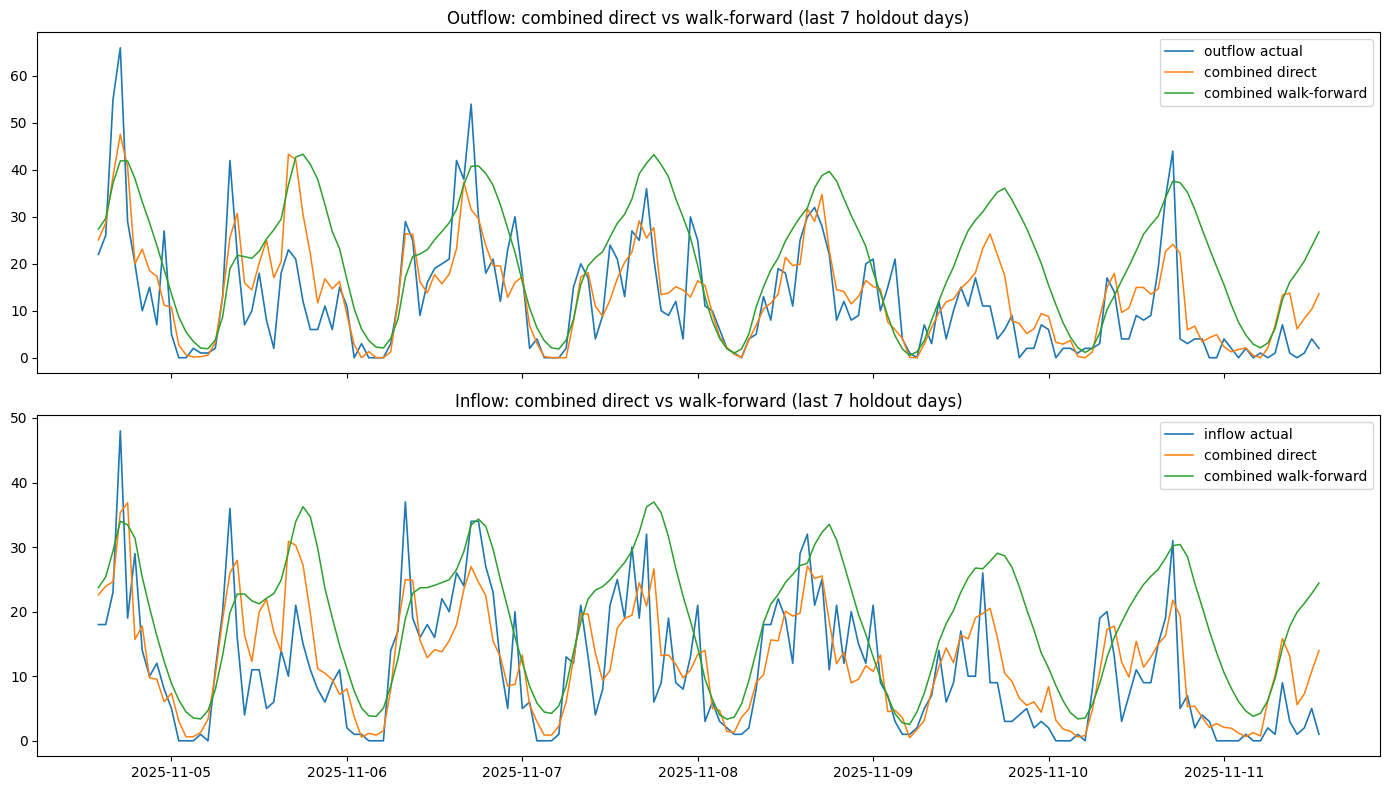

In [53]:
# Task 4.3: combined-input models + walk-forward evaluation (stay within Task 4).

def make_calendar_features(ts: pd.Timestamp) -> dict:
    h = ts.hour
    d = ts.dayofweek
    return {
        "hour_sin": np.sin(2 * np.pi * h / 24.0),
        "hour_cos": np.cos(2 * np.pi * h / 24.0),
        "dow_sin": np.sin(2 * np.pi * d / 7.0),
        "dow_cos": np.cos(2 * np.pi * d / 7.0),
        "is_weekend": int(d >= 5),
    }

def build_multivar_features(base_df: pd.DataFrame, target_col: str) -> pd.DataFrame:
    other_col = "inflow" if target_col == "outflow" else "outflow"
    df = base_df[["ts_hour", target_col, other_col]].copy()

    # Calendar features.
    df["hour"] = df["ts_hour"].dt.hour
    df["dow"] = df["ts_hour"].dt.dayofweek
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24.0)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24.0)
    df["dow_sin"] = np.sin(2 * np.pi * df["dow"] / 7.0)
    df["dow_cos"] = np.cos(2 * np.pi * df["dow"] / 7.0)
    df["is_weekend"] = (df["dow"] >= 5).astype(int)

    # Target and cross-signal lag features.
    lags = [1, 2, 24, 48, 168]
    for l in lags:
        df[f"{target_col}_lag_{l}"] = df[target_col].shift(l)
        df[f"{other_col}_lag_{l}"] = df[other_col].shift(l)

    # Shifted rolling means to avoid leakage.
    df[f"{target_col}_roll_6"] = df[target_col].shift(1).rolling(6).mean()
    df[f"{target_col}_roll_24"] = df[target_col].shift(1).rolling(24).mean()
    df[f"{other_col}_roll_6"] = df[other_col].shift(1).rolling(6).mean()
    df[f"{other_col}_roll_24"] = df[other_col].shift(1).rolling(24).mean()

    return df

def build_feature_row_from_history(history_df: pd.DataFrame, ts: pd.Timestamp, target_col: str) -> pd.DataFrame:
    other_col = "inflow" if target_col == "outflow" else "outflow"
    hist = history_df.sort_values("ts_hour").reset_index(drop=True)

    def lag_val(col: str, l: int) -> float:
        return float(hist[col].iloc[-l])

    def roll_val(col: str, w: int) -> float:
        return float(hist[col].iloc[-w:].mean())

    row = make_calendar_features(ts)
    for l in [1, 2, 24, 48, 168]:
        row[f"{target_col}_lag_{l}"] = lag_val(target_col, l)
        row[f"{other_col}_lag_{l}"] = lag_val(other_col, l)
    row[f"{target_col}_roll_6"] = roll_val(target_col, 6)
    row[f"{target_col}_roll_24"] = roll_val(target_col, 24)
    row[f"{other_col}_roll_6"] = roll_val(other_col, 6)
    row[f"{other_col}_roll_24"] = roll_val(other_col, 24)

    return pd.DataFrame([row])

def fit_multivar_direct(base_df: pd.DataFrame, target_col: str, holdout_n: int, alpha: float = 5.0):
    feat = build_multivar_features(base_df, target_col).dropna().reset_index(drop=True)
    split_ts = base_df["ts_hour"].iloc[-holdout_n]
    train = feat[feat["ts_hour"] < split_ts].copy()
    test = feat[feat["ts_hour"] >= split_ts].copy()

    feature_cols = [c for c in feat.columns if c not in ["ts_hour", "hour", "dow", "inflow", "outflow", target_col]]
    X_train = train[feature_cols].to_numpy(dtype=float)
    y_train = train[target_col].to_numpy(dtype=float)
    X_test = test[feature_cols].to_numpy(dtype=float)
    y_test = test[target_col].to_numpy(dtype=float)

    beta, x_mean, x_std = fit_ridge_closed_form(X_train, y_train, alpha=alpha)
    y_hat = np.clip(predict_ridge(X_test, beta, x_mean, x_std, y_train.mean()), 0, None)

    pred = test[["ts_hour"]].copy()
    pred["actual"] = y_test
    pred["pred"] = y_hat
    pred["abs_err"] = (pred["actual"] - pred["pred"]).abs()
    return pred, feature_cols, (beta, x_mean, x_std, y_train.mean())

def walk_forward_recursive(base_df: pd.DataFrame, holdout_n: int, out_model, in_model, out_features, in_features):
    split_ts = base_df["ts_hour"].iloc[-holdout_n]
    history = base_df[base_df["ts_hour"] < split_ts][["ts_hour", "inflow", "outflow"]].copy()
    future = base_df[base_df["ts_hour"] >= split_ts][["ts_hour", "inflow", "outflow"]].copy().reset_index(drop=True)

    out_beta, out_mean, out_std, out_y_mean = out_model
    in_beta, in_mean, in_std, in_y_mean = in_model

    rec = []
    for _, r in future.iterrows():
        ts = r["ts_hour"]

        x_out = build_feature_row_from_history(history, ts, "outflow")[out_features].to_numpy(dtype=float)
        x_in = build_feature_row_from_history(history, ts, "inflow")[in_features].to_numpy(dtype=float)

        pred_out = float(np.clip(predict_ridge(x_out, out_beta, out_mean, out_std, out_y_mean)[0], 0, None))
        pred_in = float(np.clip(predict_ridge(x_in, in_beta, in_mean, in_std, in_y_mean)[0], 0, None))

        rec.append({
            "ts_hour": ts,
            "out_actual": float(r["outflow"]),
            "out_pred": pred_out,
            "in_actual": float(r["inflow"]),
            "in_pred": pred_in,
        })

        # Recursive step: append predictions as the known state for next horizon step.
        history = pd.concat([
            history,
            pd.DataFrame([{
                "ts_hour": ts,
                "inflow": pred_in,
                "outflow": pred_out,
            }])
        ], ignore_index=True)

    return pd.DataFrame(rec)

holdout_n = model_holdout if "model_holdout" in globals() else holdout_hours
base = hourly_pd[["ts_hour", "inflow", "outflow"]].copy()

# Direct one-step combined-input models (still separate outputs).
out_comb_direct, out_feat_cols, out_model = fit_multivar_direct(base, "outflow", holdout_n=holdout_n, alpha=5.0)
in_comb_direct, in_feat_cols, in_model = fit_multivar_direct(base, "inflow", holdout_n=holdout_n, alpha=5.0)

# Recursive walk-forward (uses predicted history in holdout).
wf = walk_forward_recursive(base, holdout_n, out_model, in_model, out_feat_cols, in_feat_cols)

# Metric comparison.
metrics_compare = pd.DataFrame([
    {
        "series": "outflow",
        "baseline_mae": float(hourly_mae_out),
        "lag_univariate_direct_mae": float(out_metrics["mae"]),
        "lag_combined_direct_mae": float(out_comb_direct["abs_err"].mean()),
        "lag_combined_walkforward_mae": float((wf["out_actual"] - wf["out_pred"]).abs().mean()),
    },
    {
        "series": "inflow",
        "baseline_mae": float(hourly_mae_in),
        "lag_univariate_direct_mae": float(in_metrics["mae"]),
        "lag_combined_direct_mae": float(in_comb_direct["abs_err"].mean()),
        "lag_combined_walkforward_mae": float((wf["in_actual"] - wf["in_pred"]).abs().mean()),
    },
])

print("Task 4.3 comparison (lower MAE is better):")
display(metrics_compare)

# Visual: combined direct vs walk-forward for outflow/inflow on recent holdout week.
plot_df = wf.copy()
plot_df = plot_df.merge(
    out_comb_direct[["ts_hour", "pred"]].rename(columns={"pred": "out_pred_comb_direct"}),
    on="ts_hour", how="left"
)
plot_df = plot_df.merge(
    in_comb_direct[["ts_hour", "pred"]].rename(columns={"pred": "in_pred_comb_direct"}),
    on="ts_hour", how="left"
)

recent_plot = plot_df.tail(24 * 7)
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(recent_plot["ts_hour"], recent_plot["out_actual"], label="outflow actual", linewidth=1.2)
axes[0].plot(recent_plot["ts_hour"], recent_plot["out_pred_comb_direct"], label="combined direct", linewidth=1.1)
axes[0].plot(recent_plot["ts_hour"], recent_plot["out_pred"], label="combined walk-forward", linewidth=1.1)
axes[0].set_title("Outflow: combined direct vs walk-forward (last 7 holdout days)")
axes[0].legend()

axes[1].plot(recent_plot["ts_hour"], recent_plot["in_actual"], label="inflow actual", linewidth=1.2)
axes[1].plot(recent_plot["ts_hour"], recent_plot["in_pred_comb_direct"], label="combined direct", linewidth=1.1)
axes[1].plot(recent_plot["ts_hour"], recent_plot["in_pred"], label="combined walk-forward", linewidth=1.1)
axes[1].set_title("Inflow: combined direct vs walk-forward (last 7 holdout days)")
axes[1].legend()

plt.tight_layout()
plt.show()

## Task 4.4 - Variable Window Evaluation for Approach 1 vs Approach 2

### Objective
Make the forecast window size configurable and evaluate both approaches under the same rolling-origin protocol.

### Approach Definitions
1. Approach 1 (Recursive): one-step models are iterated hour-by-hour up to `eval_window_hours`.
2. Approach 2 (Direct Multi-Horizon): train horizon-specific models for `h=1..eval_window_hours`.

### Exit Criteria
- `eval_window_hours` can be changed in one place.
- Performance table reported for both approaches on inflow and outflow.
- Horizon-wise error profile reported for both approaches.

eval_window_hours: 12
holdout_n: 336
rolling origins: 325
origin range: 2025-10-28 13:00:00 to 2025-11-11 01:00:00
Window-level performance (lower MAE is better):


,approach,window_hours,n_origins,n_forecasts,outflow_mae,inflow_mae,net_flow_mae
0,approach_1_recursive,12,325,3900,6.803951,6.101982,4.461913
1,approach_2_direct_multi_h,12,325,3900,7.776258,6.611992,4.713785


Horizon-wise MAE profile:


,approach,h,outflow_mae,inflow_mae
0,approach_1_recursive,1,5.475275,5.018334
1,approach_1_recursive,2,6.507772,5.838014
2,approach_1_recursive,3,6.790206,6.139691
3,approach_1_recursive,4,6.875489,6.230012
4,approach_1_recursive,5,6.895139,6.236018
5,approach_1_recursive,6,6.929307,6.234555
6,approach_1_recursive,7,6.946604,6.185341
7,approach_1_recursive,8,7.000646,6.222549
8,approach_1_recursive,9,7.014099,6.244291
9,approach_1_recursive,10,7.036344,6.262956


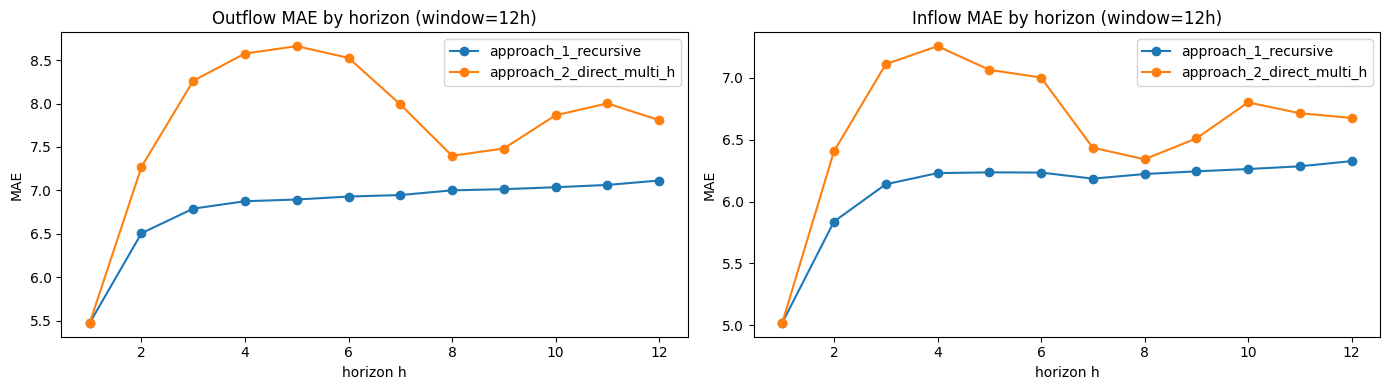

In [54]:
# Task 4.4: configurable window evaluation for both approaches.

# You can change this to 6, 12, 24, etc.
eval_window_hours = 12
alpha_direct = 5.0

base_eval = hourly_pd[["ts_hour", "inflow", "outflow"]].copy().reset_index(drop=True)
n_total = len(base_eval)
split_idx = n_total - holdout_n

if eval_window_hours < 1:
    raise ValueError("eval_window_hours must be >= 1")
if split_idx <= 200:
    raise ValueError("Not enough pre-holdout history for robust multi-horizon training")
if n_total - split_idx <= eval_window_hours:
    raise ValueError("Holdout segment must be longer than eval_window_hours")

# Rolling-origin windows: each origin forecasts the next eval_window_hours.
origin_start = split_idx - 1
origin_end = n_total - eval_window_hours - 1
origin_indices = list(range(origin_start, origin_end + 1))

if not origin_indices:
    raise ValueError("No valid rolling origins for the selected eval_window_hours")

print("eval_window_hours:", eval_window_hours)
print("holdout_n:", holdout_n)
print("rolling origins:", len(origin_indices))
print("origin range:", base_eval.loc[origin_start, "ts_hour"], "to", base_eval.loc[origin_end, "ts_hour"])


def train_direct_horizon_models(base_df: pd.DataFrame, target_col: str, split_idx: int, max_h: int, alpha: float = 5.0):
    models = {}
    feature_cols = None

    # Need enough history for lag_168 and rolling stats.
    min_origin_idx = 168

    for h in range(1, max_h + 1):
        X_rows = []
        y_vals = []

        # Training origins are restricted to pre-holdout labels.
        last_train_origin = split_idx - h - 1
        for i in range(min_origin_idx, last_train_origin + 1):
            history = base_df.iloc[: i + 1][["ts_hour", "inflow", "outflow"]].copy()
            ts_target = base_df.iloc[i]["ts_hour"] + pd.Timedelta(hours=h)

            feat_row = build_feature_row_from_history(history, ts_target, target_col)
            if feature_cols is None:
                feature_cols = feat_row.columns.tolist()

            X_rows.append(feat_row[feature_cols].iloc[0].to_numpy(dtype=float))
            y_vals.append(float(base_df.iloc[i + h][target_col]))

        if len(X_rows) < 200:
            raise ValueError(
                f"Insufficient training rows for target={target_col}, horizon={h}: {len(X_rows)}"
            )

        X_train = np.vstack(X_rows)
        y_train = np.array(y_vals, dtype=float)
        beta, x_mean, x_std = fit_ridge_closed_form(X_train, y_train, alpha=alpha)

        models[h] = {
            "beta": beta,
            "x_mean": x_mean,
            "x_std": x_std,
            "y_mean": float(y_train.mean()),
            "feature_cols": feature_cols,
            "n_train": int(len(y_train)),
        }

    return models


# Approach 2: train direct multi-horizon models once per target.
out_direct_models = train_direct_horizon_models(base_eval, "outflow", split_idx, eval_window_hours, alpha=alpha_direct)
in_direct_models = train_direct_horizon_models(base_eval, "inflow", split_idx, eval_window_hours, alpha=alpha_direct)


def eval_recursive_window(base_df: pd.DataFrame, origin_idx: int, window_h: int):
    history = base_df.iloc[: origin_idx + 1][["ts_hour", "inflow", "outflow"]].copy().reset_index(drop=True)
    origin_ts = base_df.iloc[origin_idx]["ts_hour"]

    rows = []
    for h in range(1, window_h + 1):
        ts_target = origin_ts + pd.Timedelta(hours=h)

        x_out = build_feature_row_from_history(history, ts_target, "outflow")[out_feat_cols].to_numpy(dtype=float)
        x_in = build_feature_row_from_history(history, ts_target, "inflow")[in_feat_cols].to_numpy(dtype=float)

        pred_out = float(np.clip(predict_ridge(x_out, out_model[0], out_model[1], out_model[2], out_model[3])[0], 0, None))
        pred_in = float(np.clip(predict_ridge(x_in, in_model[0], in_model[1], in_model[2], in_model[3])[0], 0, None))

        actual_out = float(base_df.iloc[origin_idx + h]["outflow"])
        actual_in = float(base_df.iloc[origin_idx + h]["inflow"])

        rows.append({
            "approach": "approach_1_recursive",
            "origin_ts": origin_ts,
            "h": h,
            "target_ts": ts_target,
            "out_actual": actual_out,
            "out_pred": pred_out,
            "in_actual": actual_in,
            "in_pred": pred_in,
        })

        history = pd.concat(
            [
                history,
                pd.DataFrame([
                    {
                        "ts_hour": ts_target,
                        "inflow": pred_in,
                        "outflow": pred_out,
                    }
                ]),
            ],
            ignore_index=True,
        )

    return rows


def eval_direct_window(base_df: pd.DataFrame, origin_idx: int, window_h: int):
    history = base_df.iloc[: origin_idx + 1][["ts_hour", "inflow", "outflow"]].copy().reset_index(drop=True)
    origin_ts = base_df.iloc[origin_idx]["ts_hour"]

    rows = []
    for h in range(1, window_h + 1):
        ts_target = origin_ts + pd.Timedelta(hours=h)

        out_m = out_direct_models[h]
        in_m = in_direct_models[h]

        x_out_df = build_feature_row_from_history(history, ts_target, "outflow")
        x_in_df = build_feature_row_from_history(history, ts_target, "inflow")

        x_out = x_out_df[out_m["feature_cols"]].to_numpy(dtype=float)
        x_in = x_in_df[in_m["feature_cols"]].to_numpy(dtype=float)

        pred_out = float(np.clip(predict_ridge(x_out, out_m["beta"], out_m["x_mean"], out_m["x_std"], out_m["y_mean"])[0], 0, None))
        pred_in = float(np.clip(predict_ridge(x_in, in_m["beta"], in_m["x_mean"], in_m["x_std"], in_m["y_mean"])[0], 0, None))

        actual_out = float(base_df.iloc[origin_idx + h]["outflow"])
        actual_in = float(base_df.iloc[origin_idx + h]["inflow"])

        rows.append({
            "approach": "approach_2_direct_multi_h",
            "origin_ts": origin_ts,
            "h": h,
            "target_ts": ts_target,
            "out_actual": actual_out,
            "out_pred": pred_out,
            "in_actual": actual_in,
            "in_pred": pred_in,
        })

    return rows


# Evaluate both approaches across the same rolling origins.
all_rows = []
for origin_idx in origin_indices:
    all_rows.extend(eval_recursive_window(base_eval, origin_idx, eval_window_hours))
    all_rows.extend(eval_direct_window(base_eval, origin_idx, eval_window_hours))

window_eval_df = pd.DataFrame(all_rows)
window_eval_df["out_abs_err"] = (window_eval_df["out_actual"] - window_eval_df["out_pred"]).abs()
window_eval_df["in_abs_err"] = (window_eval_df["in_actual"] - window_eval_df["in_pred"]).abs()

summary_rows = []
for approach_name, g in window_eval_df.groupby("approach"):
    summary_rows.append(
        {
            "approach": approach_name,
            "window_hours": eval_window_hours,
            "n_origins": int(g["origin_ts"].nunique()),
            "n_forecasts": int(len(g)),
            "outflow_mae": float(g["out_abs_err"].mean()),
            "inflow_mae": float(g["in_abs_err"].mean()),
            "net_flow_mae": float(((g["in_actual"] - g["out_actual"]) - (g["in_pred"] - g["out_pred"])).abs().mean()),
        }
    )
summary_df = pd.DataFrame(summary_rows).sort_values("outflow_mae").reset_index(drop=True)

horizon_profile_df = (
    window_eval_df
    .groupby(["approach", "h"], as_index=False)
    .agg(
        outflow_mae=("out_abs_err", "mean"),
        inflow_mae=("in_abs_err", "mean"),
    )
)

print("Window-level performance (lower MAE is better):")
display(summary_df)

print("Horizon-wise MAE profile:")
display(horizon_profile_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)
for approach_name, g in horizon_profile_df.groupby("approach"):
    axes[0].plot(g["h"], g["outflow_mae"], marker="o", label=approach_name)
    axes[1].plot(g["h"], g["inflow_mae"], marker="o", label=approach_name)

axes[0].set_title(f"Outflow MAE by horizon (window={eval_window_hours}h)")
axes[0].set_xlabel("horizon h")
axes[0].set_ylabel("MAE")
axes[0].legend()

axes[1].set_title(f"Inflow MAE by horizon (window={eval_window_hours}h)")
axes[1].set_xlabel("horizon h")
axes[1].set_ylabel("MAE")
axes[1].legend()

plt.tight_layout()
plt.show()

## Task 4.5 - Advanced Model Dependency Gate

### Objective
Check whether `statsmodels` (for SARIMAX) and `catboost` are available in the current kernel before running advanced model benchmarks.

### Rule
If dependencies are unavailable, we do not install packages automatically; we pause and request your help.

In [56]:
# Task 4.5: dependency gate for advanced models.
import importlib.util

HAS_STATSMODELS = importlib.util.find_spec("statsmodels") is not None
HAS_CATBOOST = importlib.util.find_spec("catboost") is not None

print("HAS_STATSMODELS:", HAS_STATSMODELS)
print("HAS_CATBOOST:", HAS_CATBOOST)

if not HAS_STATSMODELS:
    print("Missing dependency: statsmodels (required for SARIMAX benchmark)")
if not HAS_CATBOOST:
    print("Missing dependency: catboost (required for CatBoost benchmark)")

HAS_STATSMODELS: True
HAS_CATBOOST: True


## Task 4.6 - SARIMAX Benchmark (Time-Series Baseline)

### Objective
Add a classical time-series benchmark using SARIMAX for inflow and outflow, evaluated with the same configurable window size.

### Notes
- This is a benchmark model, not yet the final production candidate.
- To keep runtime practical, we evaluate on a recent rolling-origin subset (`sarimax_max_origins`).

### Exit Criteria
- SARIMAX window MAE is reported for inflow/outflow/net flow.
- Horizon-wise MAE profile is reported for comparison.

sarimax_max_origins: 24
sarimax_origins used: 24
sarimax_order: (1, 0, 1) seasonal: (1, 0, 1, 24)
SARIMAX benchmark summary (subset rolling origins):


,approach,window_hours,n_origins,n_forecasts,outflow_mae,inflow_mae,net_flow_mae
0,approach_3_sarimax_benchmark,12,24,288,7.92572,7.013743,2.860516


SARIMAX horizon profile:


,h,outflow_mae,inflow_mae
0,1,4.680221,3.537831
1,2,5.792820,4.693650
2,3,6.433865,5.339915
3,4,7.007561,5.839738
4,5,7.400232,6.397081
5,6,7.721101,6.983043
6,7,8.313979,7.674260
7,8,9.026130,8.246790
8,9,9.338042,8.426364
9,10,9.549209,8.701780


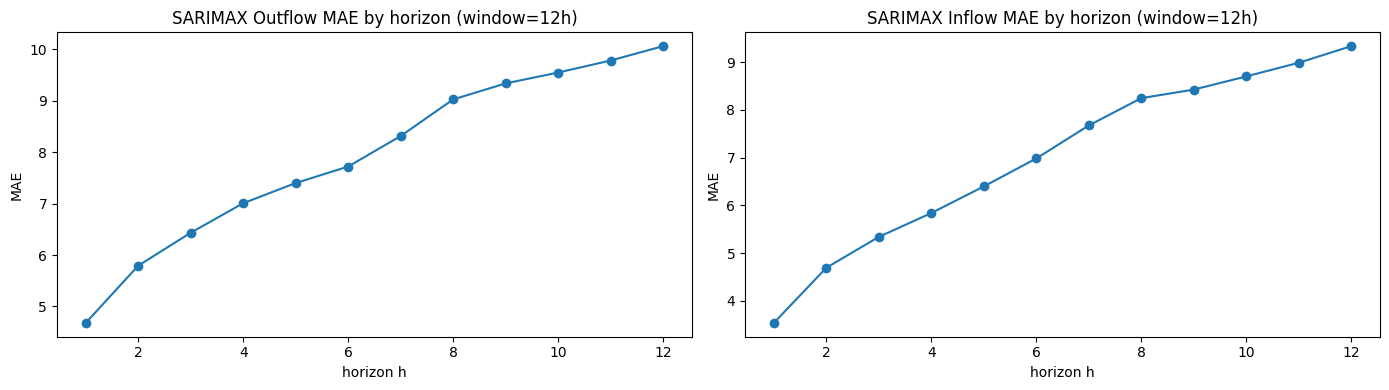

In [57]:
# Task 4.6: SARIMAX benchmark on a recent rolling-origin subset.
from statsmodels.tsa.statespace.sarimax import SARIMAX

if "base_eval" not in globals() or "origin_indices" not in globals() or "eval_window_hours" not in globals():
    raise ValueError("Please run Task 4.4 first (base_eval/origin_indices/eval_window_hours are required).")

# Runtime control for SARIMAX rolling fits.
sarimax_max_origins = 24
sarimax_origins = origin_indices[-sarimax_max_origins:] if len(origin_indices) > sarimax_max_origins else origin_indices

sarimax_order = (1, 0, 1)
sarimax_seasonal_order = (1, 0, 1, 24)

print("sarimax_max_origins:", sarimax_max_origins)
print("sarimax_origins used:", len(sarimax_origins))
print("sarimax_order:", sarimax_order, "seasonal:", sarimax_seasonal_order)


def sarimax_forecast_window(series: pd.Series, origin_idx: int, window_h: int):
    train_series = series.iloc[: origin_idx + 1].astype(float)
    model = SARIMAX(
        train_series,
        order=sarimax_order,
        seasonal_order=sarimax_seasonal_order,
        trend="c",
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    fit = model.fit(disp=False)
    pred = fit.forecast(steps=window_h)
    pred = np.clip(np.asarray(pred, dtype=float), 0, None)
    return pred

sarimax_rows = []
for origin_idx in sarimax_origins:
    origin_ts = base_eval.iloc[origin_idx]["ts_hour"]

    out_pred = sarimax_forecast_window(base_eval["outflow"], origin_idx, eval_window_hours)
    in_pred = sarimax_forecast_window(base_eval["inflow"], origin_idx, eval_window_hours)

    for h in range(1, eval_window_hours + 1):
        target_ts = base_eval.iloc[origin_idx + h]["ts_hour"]
        sarimax_rows.append(
            {
                "approach": "approach_3_sarimax_benchmark",
                "origin_ts": origin_ts,
                "h": h,
                "target_ts": target_ts,
                "out_actual": float(base_eval.iloc[origin_idx + h]["outflow"]),
                "out_pred": float(out_pred[h - 1]),
                "in_actual": float(base_eval.iloc[origin_idx + h]["inflow"]),
                "in_pred": float(in_pred[h - 1]),
            }
        )

sarimax_eval_df = pd.DataFrame(sarimax_rows)
sarimax_eval_df["out_abs_err"] = (sarimax_eval_df["out_actual"] - sarimax_eval_df["out_pred"]).abs()
sarimax_eval_df["in_abs_err"] = (sarimax_eval_df["in_actual"] - sarimax_eval_df["in_pred"]).abs()

sarimax_summary_df = pd.DataFrame([
    {
        "approach": "approach_3_sarimax_benchmark",
        "window_hours": int(eval_window_hours),
        "n_origins": int(sarimax_eval_df["origin_ts"].nunique()),
        "n_forecasts": int(len(sarimax_eval_df)),
        "outflow_mae": float(sarimax_eval_df["out_abs_err"].mean()),
        "inflow_mae": float(sarimax_eval_df["in_abs_err"].mean()),
        "net_flow_mae": float(((sarimax_eval_df["in_actual"] - sarimax_eval_df["out_actual"]) - (sarimax_eval_df["in_pred"] - sarimax_eval_df["out_pred"])).abs().mean()),
    }
])

sarimax_horizon_profile_df = (
    sarimax_eval_df
    .groupby("h", as_index=False)
    .agg(
        outflow_mae=("out_abs_err", "mean"),
        inflow_mae=("in_abs_err", "mean"),
    )
)

print("SARIMAX benchmark summary (subset rolling origins):")
display(sarimax_summary_df)
print("SARIMAX horizon profile:")
display(sarimax_horizon_profile_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)
axes[0].plot(sarimax_horizon_profile_df["h"], sarimax_horizon_profile_df["outflow_mae"], marker="o")
axes[0].set_title(f"SARIMAX Outflow MAE by horizon (window={eval_window_hours}h)")
axes[0].set_xlabel("horizon h")
axes[0].set_ylabel("MAE")

axes[1].plot(sarimax_horizon_profile_df["h"], sarimax_horizon_profile_df["inflow_mae"], marker="o")
axes[1].set_title(f"SARIMAX Inflow MAE by horizon (window={eval_window_hours}h)")
axes[1].set_xlabel("horizon h")
axes[1].set_ylabel("MAE")

plt.tight_layout()
plt.show()

## Task 4.7 - CatBoost Direct Multi-Horizon Benchmark

### Objective
Train nonlinear CatBoost models for inflow/outflow with a direct multi-horizon strategy and compare against Ridge (Approach 1/2) and SARIMAX.

### Notes
- Uses the same configurable `eval_window_hours` from Task 4.4.
- Uses a recent rolling-origin subset (`catboost_max_origins`) for runtime control and fair comparison.

### Exit Criteria
- CatBoost summary and horizon profile are reported.
- An aligned comparison table is produced for all available approaches on the same origin subset.

catboost_max_origins: 24
catboost_origins used: 24
eval_window_hours: 12
CatBoost benchmark summary:


,approach,window_hours,n_origins,n_forecasts,outflow_mae,inflow_mae,net_flow_mae
0,approach_4_catboost_direct_multi_h,12,24,288,4.793301,3.690317,2.824993


CatBoost horizon profile:


,h,outflow_mae,inflow_mae
0,1,3.786347,2.394794
1,2,4.516123,3.310744
2,3,4.513852,3.052432
3,4,5.047762,3.472889
4,5,4.317392,3.719163
5,6,4.413976,3.617159
6,7,4.394894,3.682029
7,8,4.526614,3.832051
8,9,4.863273,4.001770
9,10,5.373738,4.361341


Aligned comparison on same origin subset (lower MAE is better):


,approach,window_hours,n_origins,n_forecasts,outflow_mae,inflow_mae,net_flow_mae
0,approach_4_catboost_direct_multi_h,12,24,288,4.793301,3.690317,2.824993
1,approach_1_recursive,12,24,288,6.195610,4.938747,3.182107
2,approach_2_direct_multi_h,12,24,288,6.602692,4.913751,3.035169
3,approach_3_sarimax_benchmark,12,24,288,7.925720,7.013743,2.860516


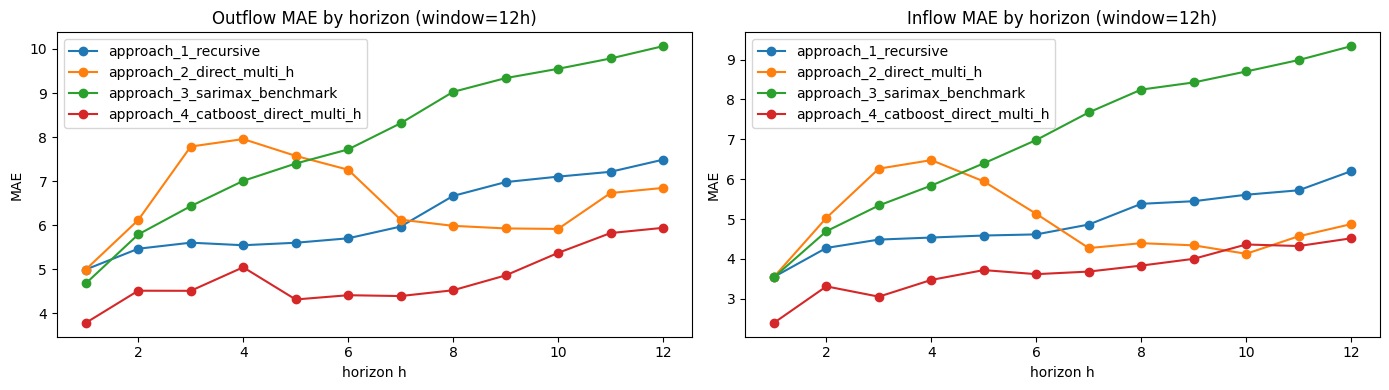

In [58]:
# Task 4.7: CatBoost direct multi-horizon benchmark + aligned comparison.

try:
    from catboost import CatBoostRegressor
except Exception as ex:
    raise ModuleNotFoundError(
        "catboost is not available in the notebook kernel. Please install it and rerun this cell."
    ) from ex

if "base_eval" not in globals() or "origin_indices" not in globals() or "eval_window_hours" not in globals():
    raise ValueError("Please run Task 4.4 first (base_eval/origin_indices/eval_window_hours are required).")

catboost_max_origins = sarimax_max_origins if "sarimax_max_origins" in globals() else 24
catboost_origins = origin_indices[-catboost_max_origins:] if len(origin_indices) > catboost_max_origins else origin_indices

print("catboost_max_origins:", catboost_max_origins)
print("catboost_origins used:", len(catboost_origins))
print("eval_window_hours:", eval_window_hours)


def build_direct_training_set(base_df: pd.DataFrame, target_col: str, horizon_h: int, split_idx_: int):
    min_origin_idx = 168
    last_train_origin = split_idx_ - horizon_h - 1

    x_rows = []
    y_vals = []
    feature_cols = None

    for i in range(min_origin_idx, last_train_origin + 1):
        history = base_df.iloc[: i + 1][["ts_hour", "inflow", "outflow"]].copy()
        ts_target = base_df.iloc[i]["ts_hour"] + pd.Timedelta(hours=horizon_h)

        feat_row = build_feature_row_from_history(history, ts_target, target_col)
        if feature_cols is None:
            feature_cols = feat_row.columns.tolist()

        x_rows.append(feat_row[feature_cols].iloc[0].to_numpy(dtype=float))
        y_vals.append(float(base_df.iloc[i + horizon_h][target_col]))

    if len(x_rows) < 200:
        raise ValueError(
            f"Insufficient rows for CatBoost target={target_col}, horizon={horizon_h}: {len(x_rows)}"
        )

    X = np.vstack(x_rows)
    y = np.array(y_vals, dtype=float)
    return X, y, feature_cols


def train_catboost_direct_models(base_df: pd.DataFrame, target_col: str, split_idx_: int, max_h: int):
    models = {}

    for h in range(1, max_h + 1):
        X_train, y_train, feature_cols = build_direct_training_set(base_df, target_col, h, split_idx_)

        model = CatBoostRegressor(
            loss_function="MAE",
            eval_metric="MAE",
            iterations=500,
            learning_rate=0.05,
            depth=6,
            random_seed=42,
            verbose=False,
        )
        model.fit(X_train, y_train)

        models[h] = {
            "model": model,
            "feature_cols": feature_cols,
            "n_train": int(len(y_train)),
        }

    return models


cb_out_models = train_catboost_direct_models(base_eval, "outflow", split_idx, eval_window_hours)
cb_in_models = train_catboost_direct_models(base_eval, "inflow", split_idx, eval_window_hours)


catboost_rows = []
for origin_idx in catboost_origins:
    origin_ts = base_eval.iloc[origin_idx]["ts_hour"]
    history = base_eval.iloc[: origin_idx + 1][["ts_hour", "inflow", "outflow"]].copy().reset_index(drop=True)

    for h in range(1, eval_window_hours + 1):
        ts_target = origin_ts + pd.Timedelta(hours=h)

        out_entry = cb_out_models[h]
        in_entry = cb_in_models[h]

        x_out_df = build_feature_row_from_history(history, ts_target, "outflow")
        x_in_df = build_feature_row_from_history(history, ts_target, "inflow")

        x_out = x_out_df[out_entry["feature_cols"]].to_numpy(dtype=float)
        x_in = x_in_df[in_entry["feature_cols"]].to_numpy(dtype=float)

        out_pred = float(np.clip(out_entry["model"].predict(x_out)[0], 0, None))
        in_pred = float(np.clip(in_entry["model"].predict(x_in)[0], 0, None))

        catboost_rows.append(
            {
                "approach": "approach_4_catboost_direct_multi_h",
                "origin_ts": origin_ts,
                "h": h,
                "target_ts": ts_target,
                "out_actual": float(base_eval.iloc[origin_idx + h]["outflow"]),
                "out_pred": out_pred,
                "in_actual": float(base_eval.iloc[origin_idx + h]["inflow"]),
                "in_pred": in_pred,
            }
        )

catboost_eval_df = pd.DataFrame(catboost_rows)
catboost_eval_df["out_abs_err"] = (catboost_eval_df["out_actual"] - catboost_eval_df["out_pred"]).abs()
catboost_eval_df["in_abs_err"] = (catboost_eval_df["in_actual"] - catboost_eval_df["in_pred"]).abs()

catboost_summary_df = pd.DataFrame([
    {
        "approach": "approach_4_catboost_direct_multi_h",
        "window_hours": int(eval_window_hours),
        "n_origins": int(catboost_eval_df["origin_ts"].nunique()),
        "n_forecasts": int(len(catboost_eval_df)),
        "outflow_mae": float(catboost_eval_df["out_abs_err"].mean()),
        "inflow_mae": float(catboost_eval_df["in_abs_err"].mean()),
        "net_flow_mae": float(((catboost_eval_df["in_actual"] - catboost_eval_df["out_actual"]) - (catboost_eval_df["in_pred"] - catboost_eval_df["out_pred"])).abs().mean()),
    }
])

catboost_horizon_profile_df = (
    catboost_eval_df
    .groupby("h", as_index=False)
    .agg(
        outflow_mae=("out_abs_err", "mean"),
        inflow_mae=("in_abs_err", "mean"),
    )
)

print("CatBoost benchmark summary:")
display(catboost_summary_df)
print("CatBoost horizon profile:")
display(catboost_horizon_profile_df)


def summarize_eval(df: pd.DataFrame, approach_name: str) -> dict:
    return {
        "approach": approach_name,
        "window_hours": int(eval_window_hours),
        "n_origins": int(df["origin_ts"].nunique()),
        "n_forecasts": int(len(df)),
        "outflow_mae": float((df["out_actual"] - df["out_pred"]).abs().mean()),
        "inflow_mae": float((df["in_actual"] - df["in_pred"]).abs().mean()),
        "net_flow_mae": float(((df["in_actual"] - df["out_actual"]) - (df["in_pred"] - df["out_pred"])).abs().mean()),
    }

aligned_rows = []
aligned_origins = set(catboost_eval_df["origin_ts"].tolist())

if "window_eval_df" in globals():
    for approach_name in ["approach_1_recursive", "approach_2_direct_multi_h"]:
        sub = window_eval_df[(window_eval_df["approach"] == approach_name) & (window_eval_df["origin_ts"].isin(aligned_origins))]
        if len(sub):
            aligned_rows.append(summarize_eval(sub, approach_name))

if "sarimax_eval_df" in globals() and len(sarimax_eval_df):
    sarimax_sub = sarimax_eval_df[sarimax_eval_df["origin_ts"].isin(aligned_origins)]
    if len(sarimax_sub):
        aligned_rows.append(summarize_eval(sarimax_sub, "approach_3_sarimax_benchmark"))

aligned_rows.append(summarize_eval(catboost_eval_df, "approach_4_catboost_direct_multi_h"))

advanced_compare_df = pd.DataFrame(aligned_rows).sort_values("outflow_mae").reset_index(drop=True)

print("Aligned comparison on same origin subset (lower MAE is better):")
display(advanced_compare_df)

# Horizon-wise comparison across available approaches.
horizon_frames = []
if "window_eval_df" in globals():
    for approach_name in ["approach_1_recursive", "approach_2_direct_multi_h"]:
        sub = window_eval_df[(window_eval_df["approach"] == approach_name) & (window_eval_df["origin_ts"].isin(aligned_origins))].copy()
        if len(sub):
            sub["out_abs_err"] = (sub["out_actual"] - sub["out_pred"]).abs()
            sub["in_abs_err"] = (sub["in_actual"] - sub["in_pred"]).abs()
            hp = sub.groupby("h", as_index=False).agg(outflow_mae=("out_abs_err", "mean"), inflow_mae=("in_abs_err", "mean"))
            hp["approach"] = approach_name
            horizon_frames.append(hp)

if "sarimax_eval_df" in globals() and len(sarimax_eval_df):
    sub = sarimax_eval_df[sarimax_eval_df["origin_ts"].isin(aligned_origins)].copy()
    if len(sub):
        sub["out_abs_err"] = (sub["out_actual"] - sub["out_pred"]).abs()
        sub["in_abs_err"] = (sub["in_actual"] - sub["in_pred"]).abs()
        hp = sub.groupby("h", as_index=False).agg(outflow_mae=("out_abs_err", "mean"), inflow_mae=("in_abs_err", "mean"))
        hp["approach"] = "approach_3_sarimax_benchmark"
        horizon_frames.append(hp)

hp_cb = catboost_horizon_profile_df.copy()
hp_cb["approach"] = "approach_4_catboost_direct_multi_h"
horizon_frames.append(hp_cb)

advanced_horizon_compare_df = pd.concat(horizon_frames, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)
for approach_name, g in advanced_horizon_compare_df.groupby("approach"):
    axes[0].plot(g["h"], g["outflow_mae"], marker="o", label=approach_name)
    axes[1].plot(g["h"], g["inflow_mae"], marker="o", label=approach_name)

axes[0].set_title(f"Outflow MAE by horizon (window={eval_window_hours}h)")
axes[0].set_xlabel("horizon h")
axes[0].set_ylabel("MAE")
axes[0].legend()

axes[1].set_title(f"Inflow MAE by horizon (window={eval_window_hours}h)")
axes[1].set_xlabel("horizon h")
axes[1].set_ylabel("MAE")
axes[1].legend()

plt.tight_layout()
plt.show()

## Task 5 - 12-Hour Stockout Simulation

### Objective
Use baseline hourly inflow/outflow forecasts to simulate cumulative bike stock and estimate potential stockout timing within horizon `X`.

### Notes
- Uses configurable `capacity_override` and `initial_bikes_override`.
- Defaults to 50% of selected capacity for initial bikes when unknown.

Stockout risk detected within horizon at: 2025-11-11 16:00:00


,ts_hour,inflow_pred,outflow_pred,net_flow_pred,cum_net_flow,projected_bikes,projected_bikes_capped
0,2025-11-11 14:00:00,16.200000,17.484211,-1.284211,-1.284211,10.715789,10.715789
1,2025-11-11 15:00:00,19.957895,24.031579,-4.073684,-5.357895,6.642105,6.642105
2,2025-11-11 16:00:00,25.147368,38.168421,-13.021053,-18.378947,-6.378947,0.000000
3,2025-11-11 17:00:00,34.473684,40.368421,-5.894737,-24.273684,-12.273684,0.000000
4,2025-11-11 18:00:00,30.042105,31.400000,-1.357895,-25.631579,-13.631579,0.000000
5,2025-11-11 19:00:00,24.157895,25.284211,-1.126316,-26.757895,-14.757895,0.000000
6,2025-11-11 20:00:00,17.094737,22.915789,-5.821053,-32.578947,-20.578947,0.000000
7,2025-11-11 21:00:00,13.221053,20.200000,-6.978947,-39.557895,-27.557895,0.000000
8,2025-11-11 22:00:00,10.757895,17.147368,-6.389474,-45.947368,-33.947368,0.000000
9,2025-11-11 23:00:00,7.621053,13.094737,-5.473684,-51.421053,-39.421053,0.000000


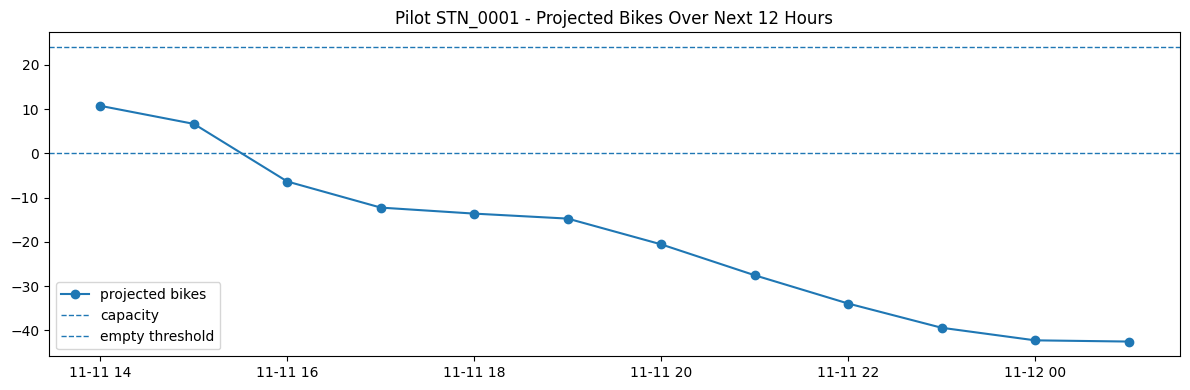

In [50]:
last_ts = hourly_model_pd["ts_hour"].max()
future_hours = pd.date_range(last_ts + pd.Timedelta(hours=1), periods=horizon_hours, freq="h")
future_df = pd.DataFrame({"ts_hour": future_hours})
future_df["dow"] = future_df["ts_hour"].dt.dayofweek
future_df["hour"] = future_df["ts_hour"].dt.hour
future_df["hour_of_week"] = future_df["dow"] * 24 + future_df["hour"]

future_df = future_df.join(how_means, on="hour_of_week", rsuffix="_pred")
future_df["inflow_pred"] = future_df["inflow"].fillna(global_means["inflow"] )
future_df["outflow_pred"] = future_df["outflow"].fillna(global_means["outflow"] )
future_df["net_flow_pred"] = future_df["inflow_pred"] - future_df["outflow_pred"]

sim_df = future_df[["ts_hour", "inflow_pred", "outflow_pred", "net_flow_pred"]].copy()
sim_df["cum_net_flow"] = sim_df["net_flow_pred"].cumsum()
sim_df["projected_bikes"] = initial_bikes + sim_df["cum_net_flow"]

if pd.notna(station_capacity):
    sim_df["projected_bikes_capped"] = sim_df["projected_bikes"].clip(lower=0, upper=station_capacity)
else:
    sim_df["projected_bikes_capped"] = sim_df["projected_bikes"]

stockout_rows = sim_df[sim_df["projected_bikes"] <= 0]
if len(stockout_rows):
    stockout_time = stockout_rows.iloc[0]["ts_hour"]
    print("Stockout risk detected within horizon at:", stockout_time)
else:
    stockout_time = None
    print("No stockout predicted within horizon.")

display(sim_df)

plt.figure(figsize=(12, 4))
plt.plot(sim_df["ts_hour"], sim_df["projected_bikes"], label="projected bikes", marker="o")
if pd.notna(station_capacity):
    plt.axhline(station_capacity, linestyle="--", linewidth=1, label="capacity")
plt.axhline(0, linestyle="--", linewidth=1, label="empty threshold")
plt.title(f"Pilot {pilot_station_id} - Projected Bikes Over Next {horizon_hours} Hours")
plt.legend()
plt.tight_layout()
plt.show()